In [91]:
from libraries import *
from parameters import *
from util import *
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib_venn import venn2

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from scipy.stats import pearsonr
from scipy.stats import spearmanr


# Sanity check — pairwise Jaccard between *FDR matrices* alone

Compare the three available DMSO FDR matrices to see which (pert, gene) cells
each one calls significant, independent of the PM values. Three pairs:

| Pair | Files |
|---|---|
| **R1 vs R2-b1** | `DMSO_FDRs.csv` (Round1 experiment) ↔ `DMSO_round2_FDRs.csv` (Round2 batch1) |
| **R1 vs R2-b2** | `DMSO_FDRs.csv` ↔ `DMSO_round2_batch2_FDRs.csv` |
| **R2-b1 vs R2-b2** | `DMSO_round2_FDRs.csv` ↔ `DMSO_round2_batch2_FDRs.csv` (the technical-replicate comparison) |

Per-perturbation Jaccard: for each pert, fraction of genes called sig by both / by either.
Per-gene Jaccard: for each gene, fraction of perts called sig by both / by either.


In [92]:
FDR_THR = 0.01

FDR_FILES = {
    'R1':    './../../FDR_matrices/DMSO_FDRs.csv',
    'R2_b1': './../../FDR_matrices/DMSO_round2_FDRs.csv',
    'R2_b2': './../../FDR_matrices/DMSO_round2_batch2_FDRs.csv',
}

fdrs = {k: pd.read_csv(p, index_col=0) for k, p in FDR_FILES.items()}
for k, v in fdrs.items():
    print(f'{k:<6}  {FDR_FILES[k]:<60}  shape={v.shape}  '
          f'frac<{FDR_THR}={(v.values<FDR_THR).mean()*100:.2f}%')

# Common axes across all three
common_perts = fdrs['R1'].index
common_genes = fdrs['R1'].columns
for k in ('R2_b1', 'R2_b2'):
    common_perts = common_perts.intersection(fdrs[k].index)
    common_genes = common_genes.intersection(fdrs[k].columns)
common_perts = sorted(common_perts); common_genes = sorted(common_genes)
print(f'\ncommon: {len(common_perts)} perts × {len(common_genes)} genes')

sig = {k: (fdrs[k].loc[common_perts, common_genes].values < FDR_THR) for k in fdrs}
print(f'\nSig-cell counts on the common slice (per matrix):')
for k, M in sig.items():
    print(f'  {k:<6} {M.sum():>9,d}  ({M.mean()*100:.2f}% of cells)')


R1      ./../../FDR_matrices/DMSO_FDRs.csv                            shape=(2334, 18151)  frac<0.01=1.49%
R2_b1   ./../../FDR_matrices/DMSO_round2_FDRs.csv                     shape=(2281, 18154)  frac<0.01=1.51%
R2_b2   ./../../FDR_matrices/DMSO_round2_batch2_FDRs.csv              shape=(2290, 18154)  frac<0.01=1.37%

common: 2215 perts × 18151 genes

Sig-cell counts on the common slice (per matrix):
  R1       618,333  (1.54% of cells)
  R2_b1    618,226  (1.54% of cells)
  R2_b2    561,454  (1.40% of cells)


In [93]:
def rowwise_jaccard_bool(A, B):
    inter = np.logical_and(A, B).sum(axis=1)
    union = np.logical_or(A, B).sum(axis=1)
    j = np.full(A.shape[0], np.nan)
    nz = union > 0; j[nz] = inter[nz] / union[nz]
    return j

def colwise_jaccard_bool(A, B):
    inter = np.logical_and(A, B).sum(axis=0)
    union = np.logical_or(A, B).sum(axis=0)
    j = np.full(A.shape[1], np.nan)
    nz = union > 0; j[nz] = inter[nz] / union[nz]
    return j

PAIRS = [
    ('R1',    'R2_b1', 'C0', 'R1 vs R2-b1'),
    ('R1',    'R2_b2', 'C1', 'R1 vs R2-b2'),
    ('R2_b1', 'R2_b2', 'C3', 'R2-b1 vs R2-b2  (technical replicates)'),
]

summary_rows = []
per_pert_jacc = {}
per_gene_jacc = {}
for a, b, _, lbl in PAIRS:
    jp = rowwise_jaccard_bool(sig[a], sig[b])
    jg = colwise_jaccard_bool(sig[a], sig[b])
    per_pert_jacc[lbl] = jp
    per_gene_jacc[lbl] = jg
    valid_p = jp[~np.isnan(jp)]
    valid_g = jg[~np.isnan(jg)]
    summary_rows.append({
        'pair':            lbl,
        'n_perts_used':    len(valid_p),
        'pert_median':     float(np.median(valid_p)) if len(valid_p) else np.nan,
        'pert_mean':       float(valid_p.mean())     if len(valid_p) else np.nan,
        'n_genes_used':    len(valid_g),
        'gene_median':     float(np.median(valid_g)) if len(valid_g) else np.nan,
        'gene_mean':       float(valid_g.mean())     if len(valid_g) else np.nan,
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False, float_format='%.4f'))


                                  pair  n_perts_used  pert_median  pert_mean  n_genes_used  gene_median  gene_mean
                           R1 vs R2-b1          2215       0.0684     0.1096         18144       0.1905     0.1871
                           R1 vs R2-b2          2215       0.0684     0.1086         18135       0.1875     0.1869
R2-b1 vs R2-b2  (technical replicates)          2215       0.0943     0.1433         18135       0.2917     0.2626


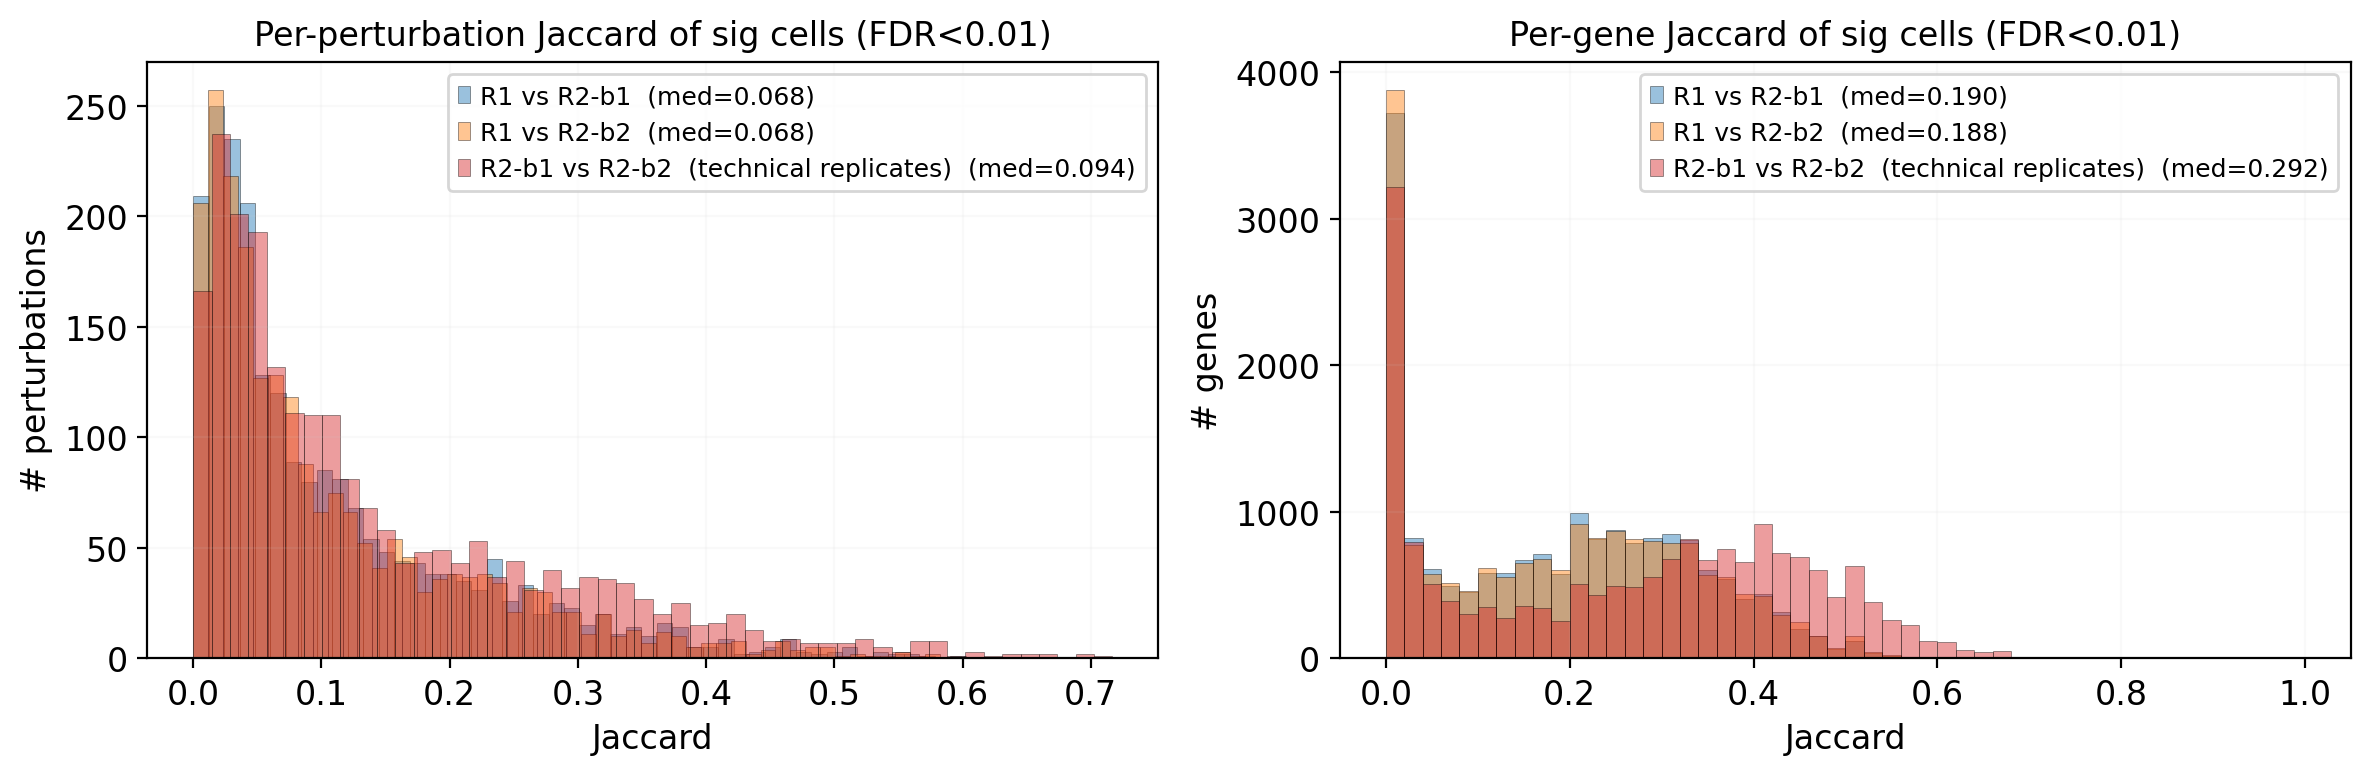

In [94]:
# Histograms — three pairs overlaid for per-pert and per-gene
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for (a, b, color, lbl) in PAIRS:
    jp = per_pert_jacc[lbl]; jp = jp[~np.isnan(jp)]
    axes[0].hist(jp, bins=50, alpha=0.45, label=f'{lbl}  (med={np.median(jp):.3f})',
                  color=color, edgecolor='black', linewidth=0.3)
axes[0].set_title(f'Per-perturbation Jaccard of sig cells (FDR<{FDR_THR})')
axes[0].set_xlabel('Jaccard'); axes[0].set_ylabel('# perturbations')
axes[0].legend(fontsize=9, loc='best'); axes[0].grid(alpha=0.1)

for (a, b, color, lbl) in PAIRS:
    jg = per_gene_jacc[lbl]; jg = jg[~np.isnan(jg)]
    axes[1].hist(jg, bins=50, alpha=0.45, label=f'{lbl}  (med={np.median(jg):.3f})',
                  color=color, edgecolor='black', linewidth=0.3)
axes[1].set_title(f'Per-gene Jaccard of sig cells (FDR<{FDR_THR})')
axes[1].set_xlabel('Jaccard'); axes[1].set_ylabel('# genes')
axes[1].legend(fontsize=9, loc='best'); axes[1].grid(alpha=0.1)

plt.tight_layout(); plt.show()


## Restrict to perturbations impacting ≥100 genes (FDR<0.01) in either Round2 batch

Apply a filter that keeps a perturbation if it has ≥100 significant genes in
`DMSO_round2_FDRs.csv` **or** `DMSO_round2_batch2_FDRs.csv`. This drops the
long tail of weak / inactive KOs whose Jaccard is dominated by a handful of
sig genes (where one extra hit shifts the ratio dramatically), and shows what
the replicate concordance looks like on the well-powered subset.


In [95]:
FDR_THR_FILTER  = 0.01
MIN_SIG_GENES   = 100

# Use the FULL R2 batch matrices to decide membership (not just the common axis)
sig_per_pert_b1 = pd.Series(
    (fdrs['R2_b1'].values < FDR_THR_FILTER).sum(axis=1),
    index=fdrs['R2_b1'].index, name='n_sig_b1')
sig_per_pert_b2 = pd.Series(
    (fdrs['R2_b2'].values < FDR_THR_FILTER).sum(axis=1),
    index=fdrs['R2_b2'].index, name='n_sig_b2')

pass_b1 = sig_per_pert_b1[sig_per_pert_b1 >= MIN_SIG_GENES].index
pass_b2 = sig_per_pert_b2[sig_per_pert_b2 >= MIN_SIG_GENES].index
selected_perts = sorted(set(pass_b1) | set(pass_b2))
print(f'Perts ≥{MIN_SIG_GENES} sig genes (FDR<{FDR_THR_FILTER}) in b1 only: {len(set(pass_b1) - set(pass_b2)):>5}')
print(f'Perts ≥{MIN_SIG_GENES} sig genes (FDR<{FDR_THR_FILTER}) in b2 only: {len(set(pass_b2) - set(pass_b1)):>5}')
print(f'Perts ≥{MIN_SIG_GENES} sig genes in BOTH:                       {len(set(pass_b1) & set(pass_b2)):>5}')
print(f'Perts in the UNION (kept):                                     {len(selected_perts):>5}')

# Restrict the (already loaded) sig matrices to (selected_perts ∩ common_perts)
sel_perts_common = [p for p in selected_perts if p in common_perts]
print(f'Of those, present on the all-3-matrices common axis:           {len(sel_perts_common):>5}')
row_idx = np.array([common_perts.index(p) for p in sel_perts_common])
sig_filt = {k: M[row_idx] for k, M in sig.items()}    # restrict rows

# Recompute per-pair summary table on the filtered set
summary_rows_f = []
per_pert_jacc_f = {}
per_gene_jacc_f = {}
for a, b, _, lbl in PAIRS:
    jp = rowwise_jaccard_bool(sig_filt[a], sig_filt[b])
    jg = colwise_jaccard_bool(sig_filt[a], sig_filt[b])
    per_pert_jacc_f[lbl] = jp
    per_gene_jacc_f[lbl] = jg
    valid_p = jp[~np.isnan(jp)]
    valid_g = jg[~np.isnan(jg)]
    summary_rows_f.append({
        'pair':            lbl,
        'n_perts_used':    len(valid_p),
        'pert_median':     float(np.median(valid_p)) if len(valid_p) else np.nan,
        'pert_mean':       float(valid_p.mean())     if len(valid_p) else np.nan,
        'n_genes_used':    len(valid_g),
        'gene_median':     float(np.median(valid_g)) if len(valid_g) else np.nan,
        'gene_mean':       float(valid_g.mean())     if len(valid_g) else np.nan,
    })
summary_df_f = pd.DataFrame(summary_rows_f)
print()
print(summary_df_f.to_string(index=False, float_format='%.4f'))


Perts ≥100 sig genes (FDR<0.01) in b1 only:   133
Perts ≥100 sig genes (FDR<0.01) in b2 only:   109
Perts ≥100 sig genes in BOTH:                         846
Perts in the UNION (kept):                                      1088
Of those, present on the all-3-matrices common axis:            1036

                                  pair  n_perts_used  pert_median  pert_mean  n_genes_used  gene_median  gene_mean
                           R1 vs R2-b1          1036       0.1588     0.1769         18132       0.2000     0.1921
                           R1 vs R2-b2          1036       0.1571     0.1760         18113       0.2000     0.1919
R2-b1 vs R2-b2  (technical replicates)          1036       0.2247     0.2350         18115       0.3000     0.2698


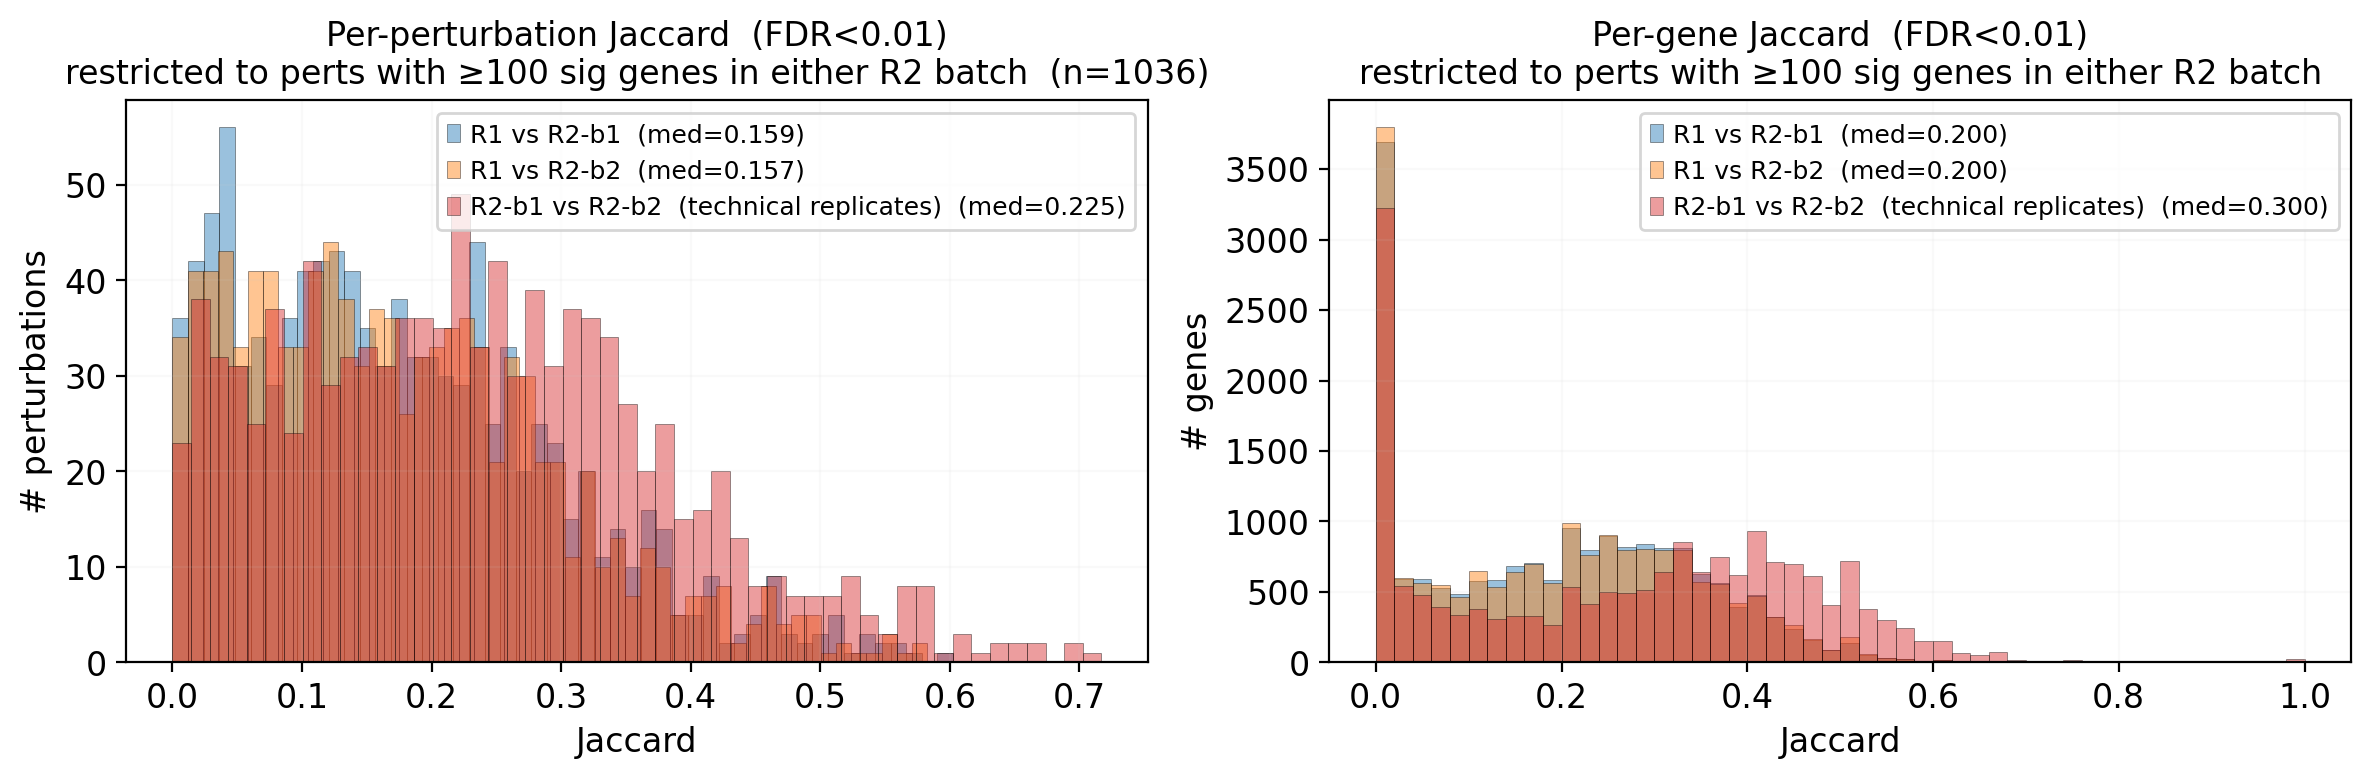

In [96]:
# Same overlay histograms, on the filtered set
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for (a, b, color, lbl) in PAIRS:
    jp = per_pert_jacc_f[lbl]; jp = jp[~np.isnan(jp)]
    axes[0].hist(jp, bins=50, alpha=0.45, label=f'{lbl}  (med={np.median(jp):.3f})',
                  color=color, edgecolor='black', linewidth=0.3)
axes[0].set_title(f'Per-perturbation Jaccard  (FDR<{FDR_THR})\n'
                   f'restricted to perts with ≥{MIN_SIG_GENES} sig genes in either R2 batch  (n={len(sel_perts_common)})')
axes[0].set_xlabel('Jaccard'); axes[0].set_ylabel('# perturbations')
axes[0].legend(fontsize=9, loc='best'); axes[0].grid(alpha=0.1)

for (a, b, color, lbl) in PAIRS:
    jg = per_gene_jacc_f[lbl]; jg = jg[~np.isnan(jg)]
    axes[1].hist(jg, bins=50, alpha=0.45, label=f'{lbl}  (med={np.median(jg):.3f})',
                  color=color, edgecolor='black', linewidth=0.3)
axes[1].set_title(f'Per-gene Jaccard  (FDR<{FDR_THR})\n'
                   f'restricted to perts with ≥{MIN_SIG_GENES} sig genes in either R2 batch')
axes[1].set_xlabel('Jaccard'); axes[1].set_ylabel('# genes')
axes[1].legend(fontsize=9, loc='best'); axes[1].grid(alpha=0.1)

plt.tight_layout(); plt.show()


In [43]:
# adata_all=sc.read_h5ad("/processed_datasets/VCI/ChemoGenetic_H1_Basak/All_control_scaled_subset.h5ad")
# dmso_sign = pd.read_csv("dmso_sign.csv")
# chir_sign = pd.read_csv("CHIR_sign.csv")


# df=chir_sign.loc[:,["perturbation","condition"]]

# # Assuming your DataFrame is called df

# cond1, cond2 = df["condition"].unique()  # the two condition names

# # sets of perturbations for each condition
# perts1 = set(df.loc[df["condition"] == cond1, "perturbation"])
# perts2 = set(df.loc[df["condition"] == cond2, "perturbation"])

# # Plot Venn
# plt.figure(figsize=(4,4))
# venn2(
#     subsets=(len(perts1 - perts2),      # unique to condition1
#              len(perts2 - perts1),      # unique to condition2
#              len(perts1 & perts2)),     # overlap
#     set_labels=(cond1, cond2)
# )

# plt.title("Overlap of Perturbations Across Replicate Conditions")
# plt.show()

# # (Optional) Print the sets
# print("Unique to", cond1, ":", perts1 - perts2)
# print("Unique to", cond2, ":", perts2 - perts1)
# print("Overlap:", perts1 & perts2)


In [97]:
dmso_fc=pd.read_csv("./../../PosteriorMeanMatrices/PosteriorMean_matrix_DMSO_round2.csv",
                    index_col=0)
dmso_fdr=pd.read_csv("./../../FDR_matrices/DMSO_round2_FDRs.csv", index_col=0)
dmso_round2_fc=pd.read_csv("./../../PosteriorMeanMatrices/PosteriorMean_matrix_DMSO_round2_batch2.csv",
                           index_col=0)
dmso_round2_fdr=pd.read_csv("./../../FDR_matrices/DMSO_round2_batch2_FDRs.csv", index_col=0)

# ============================================================
# 1. Find common perturbations (rows) across all dataframes
# ============================================================
common_perts = (dmso_fc.index
                .intersection(dmso_round2_fc.index)
                .intersection(dmso_fdr.index)
                .intersection(dmso_round2_fdr.index))

print(f"Common perturbations: {len(common_perts)}")

# ============================================================
# 2. Find common genes (columns) across all dataframes
# ============================================================
common_genes = (dmso_fc.columns
                .intersection(dmso_round2_fc.columns)
                .intersection(dmso_fdr.columns)
                .intersection(dmso_round2_fdr.columns))

print(f"Common genes: {len(common_genes)}")

# ============================================================
# 3. Align all dataframes to common rows and columns
# ============================================================
dmso_fc = dmso_fc.loc[common_perts, common_genes]
dmso_round2_fc = dmso_round2_fc.loc[common_perts, common_genes]
dmso_fdr = dmso_fdr.loc[common_perts, common_genes]
dmso_round2_fdr = dmso_round2_fdr.loc[common_perts, common_genes]

# ============================================================
# 4. Zero out non-significant values (FDR > 0.1)
# ============================================================
dmso_fc_zeroed = dmso_fc.copy()
dmso_fc_zeroed[dmso_fdr > 0.01] = 0

dmso_round2_fc_zeroed = dmso_round2_fc.copy()
dmso_round2_fc_zeroed[dmso_round2_fdr > 0.01] = 0




Common perturbations: 2184
Common genes: 18154


Correlation of #positive values:  r = 0.981
Correlation of #negative values:  r = 0.980
Correlation of #zero values:      r = 0.987
Correlation of #total (pos+neg):  r = 0.987


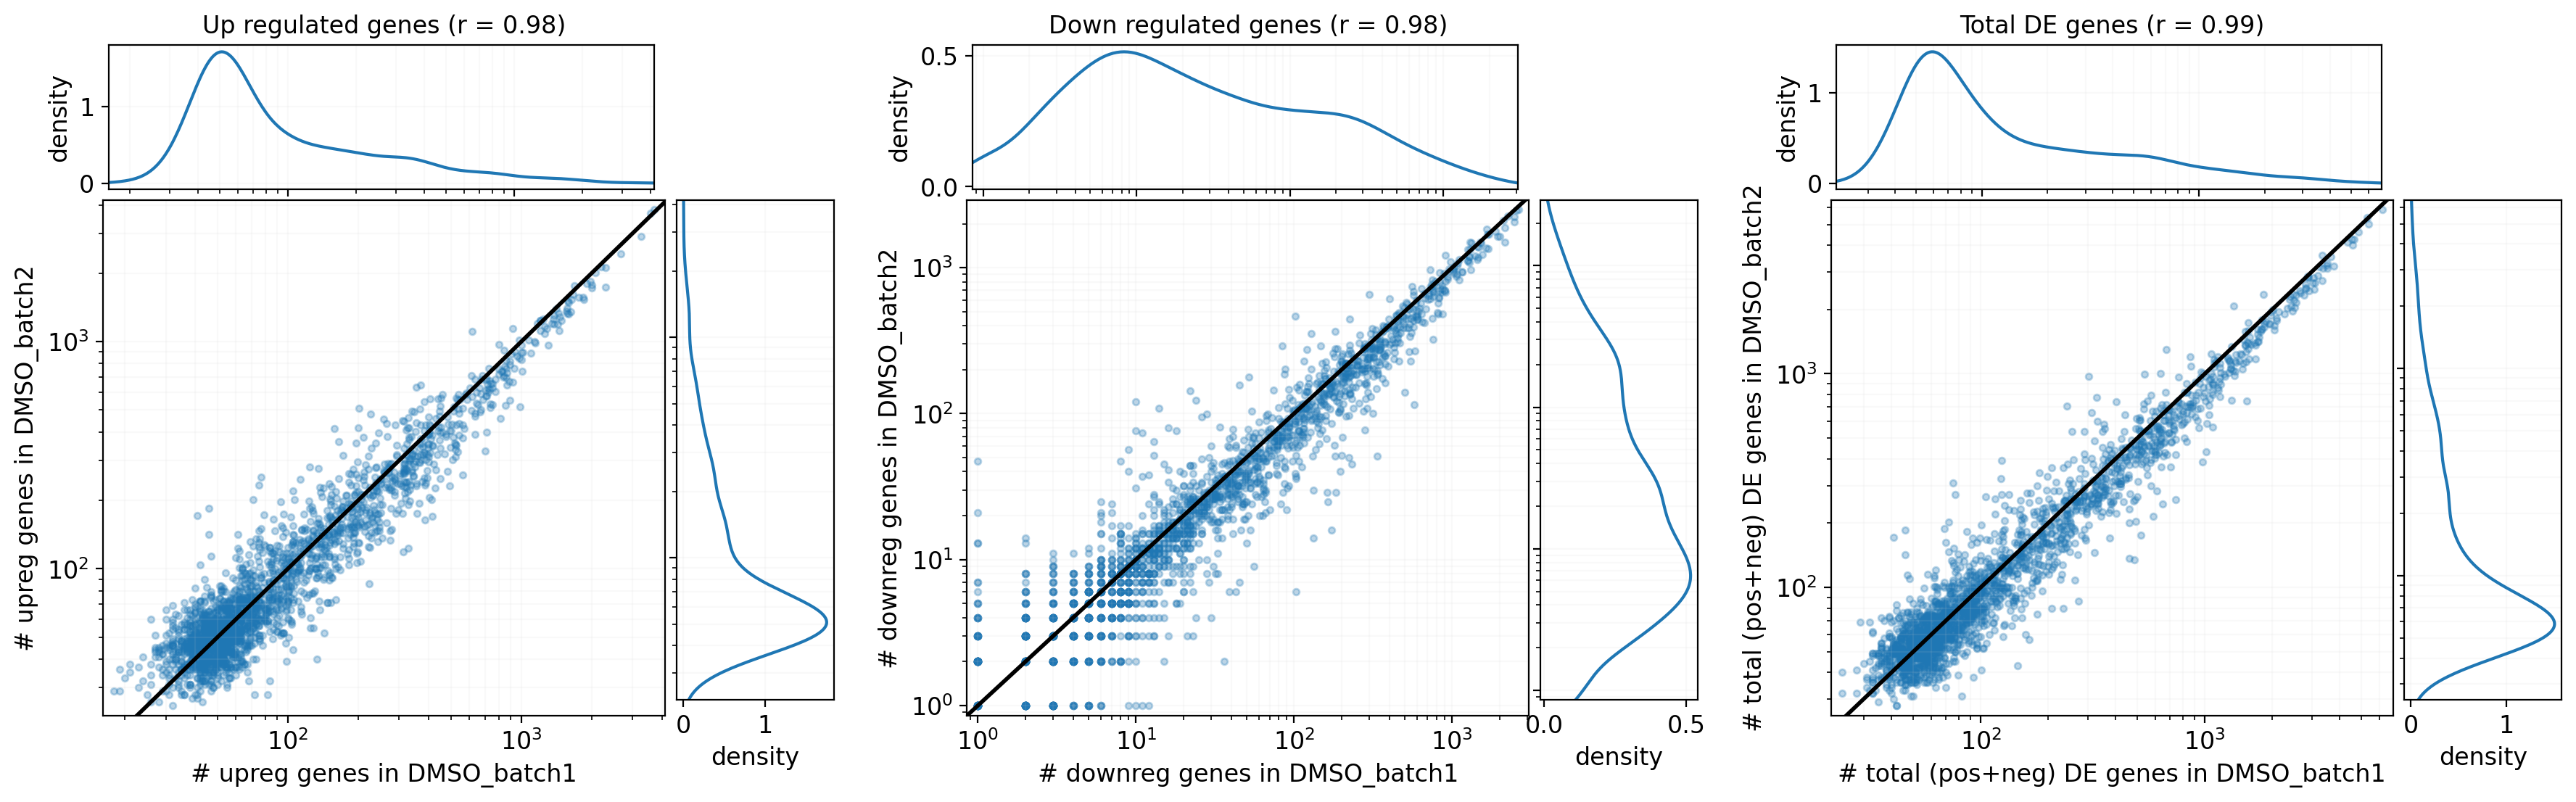

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


def _scatter_with_marginals(ax, x, y, title, xlabel, ylabel, pad_frac=0.02, kde_points=300):
    x = np.asarray(x)
    y = np.asarray(y)

    # Keep only positive finite values (log-safe), JOINTLY so x and y stay aligned
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]

    # ---- Fix limits ONCE (log-space padding) ----
    lxmin, lxmax = np.log10(x.min()), np.log10(x.max())
    lymin, lymax = np.log10(y.min()), np.log10(y.max())
    lxpad = (lxmax - lxmin) * pad_frac
    lypad = (lymax - lymin) * pad_frac

    xlim = (10 ** (lxmin - lxpad), 10 ** (lxmax + lxpad))
    ylim = (10 ** (lymin - lypad), 10 ** (lymax + lypad))
    

    # ---- Main scatter ----
    ax.scatter(x, y, s=10, alpha=0.3)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.1, which="both")

    # x = y line (same visible range)
    lo = max(xlim[0], ylim[0])
    hi = min(xlim[1], ylim[1])
    ax.plot([lo, hi], [lo, hi], linewidth=2, color="black")

    # ---- KDE in log-space, plotted back in data space ----
    log_x = np.log10(x)
    log_y = np.log10(y)

    kde_x = gaussian_kde(log_x)
    kde_y = gaussian_kde(log_y)

    # Build KDE grids from the SAME scatter limits -> perfect alignment
    gx = np.linspace(np.log10(xlim[0]), np.log10(xlim[1]), kde_points)
    gy = np.linspace(np.log10(ylim[0]), np.log10(ylim[1]), kde_points)

    dx = kde_x(gx)
    dy = kde_y(gy)

    # ---- Top density (x) ----
    ax_top = ax.inset_axes([0.01, 1.02, 0.97, 0.28])  # [left, bottom, width, height] in axes fraction
    ax_top.plot(10 ** gx, dx)
    ax_top.set_xscale("log")
    ax_top.set_xlim(*xlim)  # FORCE exact match
    ax_top.tick_params(axis="x", labelbottom=False)
    ax_top.set_ylabel("density")
    ax_top.grid(alpha=0.1, which="both")

    # ---- Right density (y) ----
    ax_right = ax.inset_axes([1.02, 0.03, 0.28, 0.97])
    ax_right.plot(dy, 10 ** gy)
    ax_right.set_yscale("log")
    ax_right.set_ylim(*ylim)  # FORCE exact match
    ax_right.tick_params(axis="y", labelleft=False)
    ax_right.set_xlabel("density")
    ax_right.grid(alpha=0.1, which="both")

    return ax


# =========================
# Your existing computation
# =========================
df1 = dmso_fc_zeroed
df2 = dmso_round2_fc_zeroed

n_pos_df1 = (df1 > 0).sum(axis=1)
n_pos_df2 = (df2 > 0).sum(axis=1)

n_neg_df1 = (df1 < 0).sum(axis=1)
n_neg_df2 = (df2 < 0).sum(axis=1)

n_zero_df1 = (df1 == 0).sum(axis=1)
n_zero_df2 = (df2 == 0).sum(axis=1)

n_total_df1 = n_pos_df1 + n_neg_df1
n_total_df2 = n_pos_df2 + n_neg_df2

corr_pos = np.corrcoef(n_pos_df1, n_pos_df2)[0, 1]
corr_neg = np.corrcoef(n_neg_df1, n_neg_df2)[0, 1]
corr_zero = np.corrcoef(n_zero_df1, n_zero_df2)[0, 1]
corr_total = np.corrcoef(n_total_df1, n_total_df2)[0, 1]

print(f"Correlation of #positive values:  r = {corr_pos:.3f}")
print(f"Correlation of #negative values:  r = {corr_neg:.3f}")
print(f"Correlation of #zero values:      r = {corr_zero:.3f}")
print(f"Correlation of #total (pos+neg):  r = {corr_total:.3f}")

# =========================
# Scatter + perfectly aligned density marginals
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

_scatter_with_marginals(
    axes[0],
    n_pos_df1, n_pos_df2,
    title=f"Up regulated genes (r = {corr_pos:.2f})",
    xlabel="# upreg genes in DMSO_batch1",
    ylabel="# upreg genes in DMSO_batch2"
)

_scatter_with_marginals(
    axes[1],
    n_neg_df1, n_neg_df2,
    title=f"Down regulated genes (r = {corr_neg:.2f})",
    xlabel="# downreg genes in DMSO_batch1",
    ylabel="# downreg genes in DMSO_batch2"
)

_scatter_with_marginals(
    axes[2],
    n_total_df1, n_total_df2,
    title=f"Total DE genes (r = {corr_total:.2f})",
    xlabel="# total (pos+neg) DE genes in DMSO_batch1",
    ylabel="# total (pos+neg) DE genes in DMSO_batch2"
)

plt.tight_layout()
plt.show()



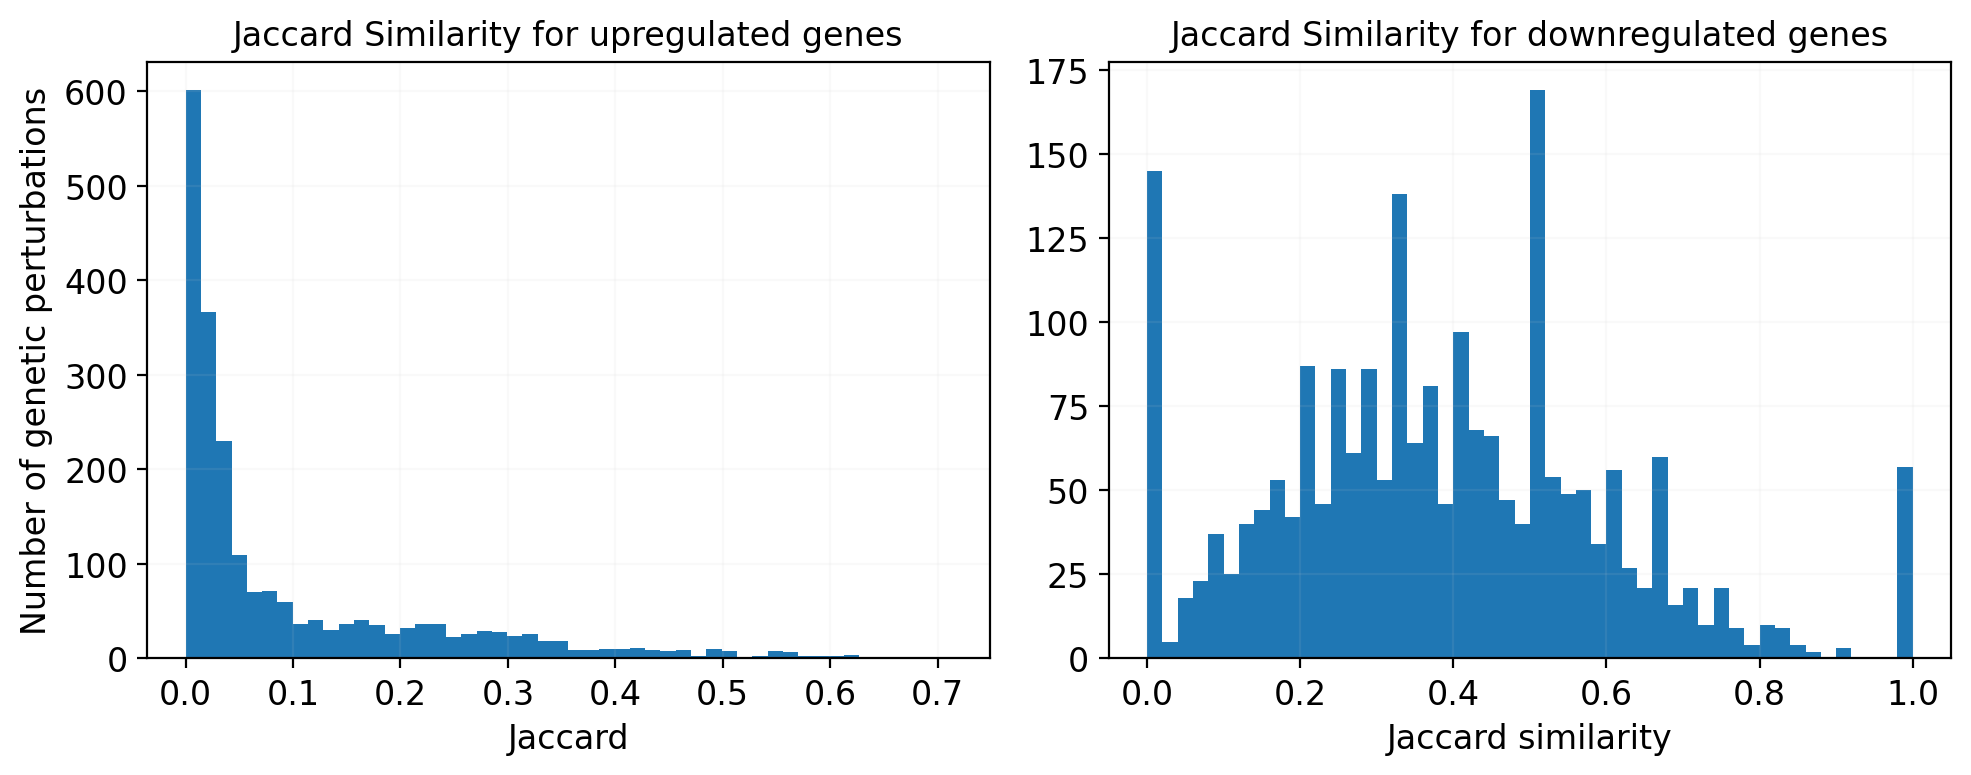

In [99]:
def rowwise_jaccard_signed_and_counts(A, B):
    """
    Computes:
      - Jaccard for positive entries per row
      - Jaccard for negative entries per row
      - #up genes per row in A and B
      - #down genes per row in A and B
    A, B: numpy arrays of shape (n_rows, n_cols)
    Returns:
      pos_jacc: (n_rows,)
      neg_jacc: (n_rows,)
      n_up_A:   (n_rows,)
      n_up_B:   (n_rows,)
      n_down_A: (n_rows,)
      n_down_B: (n_rows,)
    """
    if A.shape != B.shape:
        raise ValueError(f"Shape mismatch: A{A.shape}, B{B.shape}")
    # Boolean masks
    A_pos = A > 0
    B_pos = B > 0
    A_neg = A < 0
    B_neg = B < 0
    # --- Positive Jaccard ---
    pos_inter = np.logical_and(A_pos, B_pos).sum(axis=1)
    pos_union = np.logical_or(A_pos, B_pos).sum(axis=1)
    pos_jacc = np.zeros(A.shape[0], dtype=float)
    nonzero = pos_union != 0
    pos_jacc[nonzero] = pos_inter[nonzero] / pos_union[nonzero]
    # --- Negative Jaccard ---
    neg_inter = np.logical_and(A_neg, B_neg).sum(axis=1)
    neg_union = np.logical_or(A_neg, B_neg).sum(axis=1)
    neg_jacc = np.zeros(A.shape[0], dtype=float)
    nonzero = neg_union != 0
    neg_jacc[nonzero] = neg_inter[nonzero] / neg_union[nonzero]
    # --- Counts of up / down genes per row ---
    n_up_A   = A_pos.sum(axis=1)
    n_up_B   = B_pos.sum(axis=1)
    n_down_A = A_neg.sum(axis=1)
    n_down_B = B_neg.sum(axis=1) 
    return pos_jacc, neg_jacc, n_up_A, n_up_B, n_down_A, n_down_B

# -------------------------------------------------------
# Example usage with your matrices A and B
# -------------------------------------------------------
# A, B: (n_rows, n_cols) numpy arrays
pos_jacc, neg_jacc, n_up_A, n_up_B, n_down_A, n_down_B = rowwise_jaccard_signed_and_counts(dmso_fc_zeroed, dmso_round2_fc_zeroed)

# Remove NaNs (rows with no union) for Jaccard plots
pos_vals = pos_jacc[~np.isnan(pos_jacc)]
neg_vals = neg_jacc[~np.isnan(neg_jacc)]

# ----------------- Histograms of Jaccard -----------------
plt.figure(figsize=(10, 4))
# Positive Jaccard
plt.subplot(1, 2, 1)
plt.hist(pos_vals, bins=50)
plt.title("Jaccard Similarity for upregulated genes")
plt.xlabel("Jaccard")
plt.ylabel("Number of genetic perturbations")
plt.grid(alpha=0.1)
# Negative Jaccard
plt.subplot(1, 2, 2)
plt.hist(neg_vals, bins=50)
plt.title("Jaccard Similarity for downregulated genes")
plt.xlabel("Jaccard similarity")
plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()



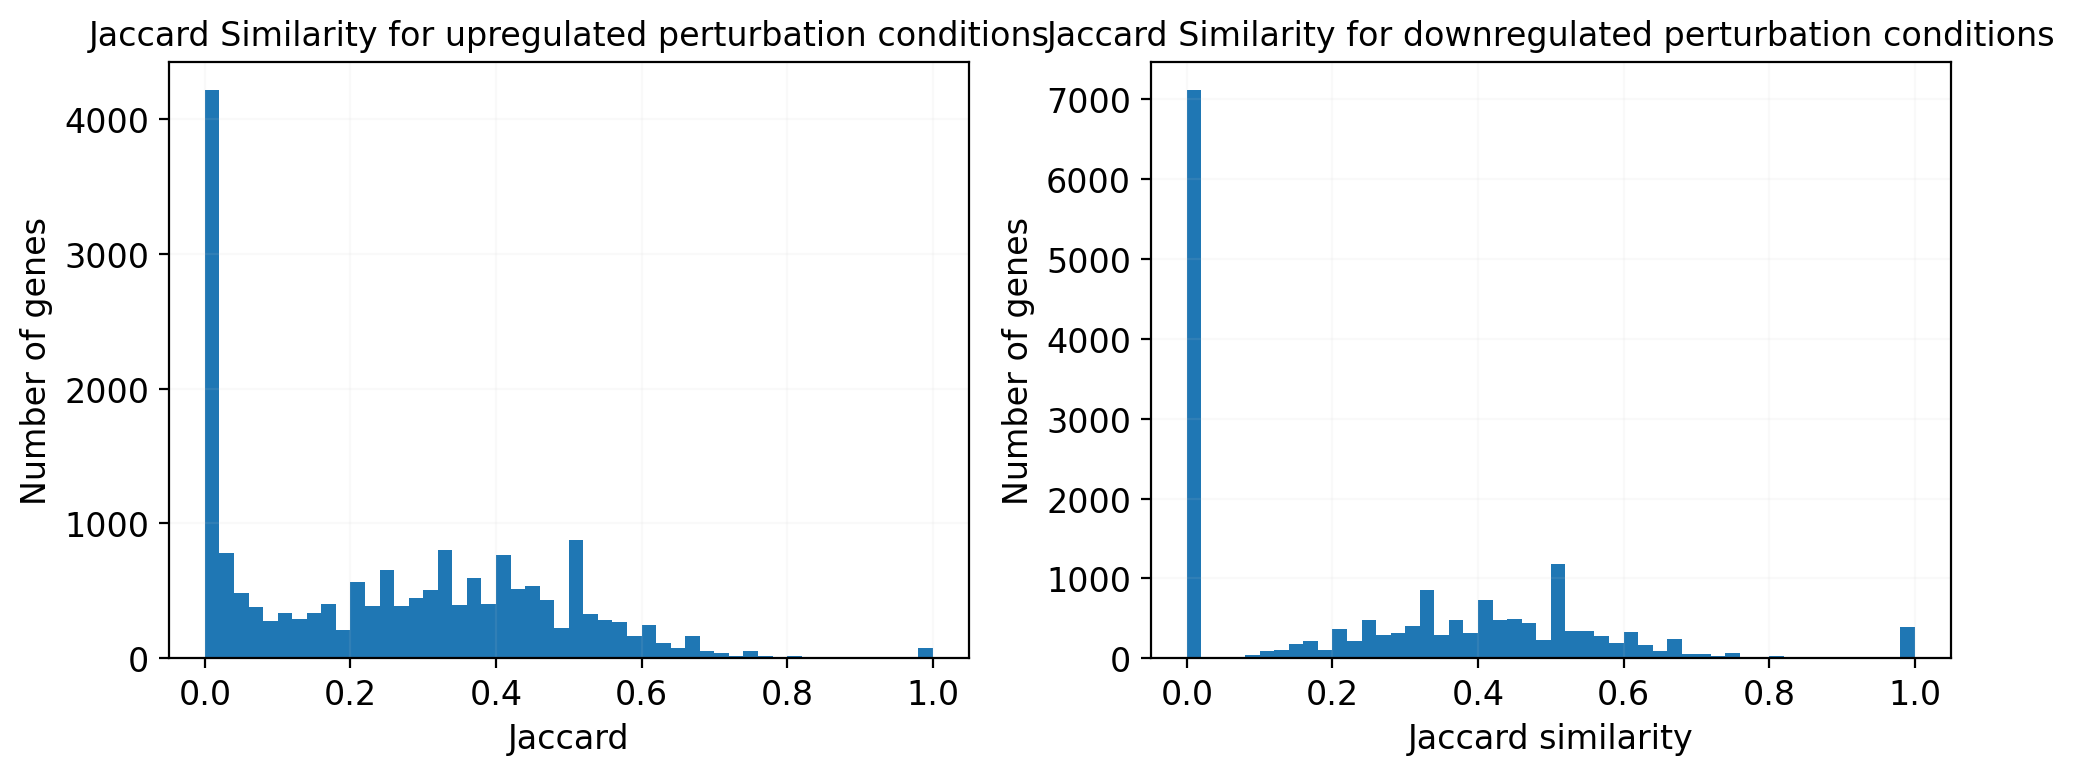

Correlation of #up perturbations per gene between A and B:   r = 0.945
Correlation of #down perturbations per gene between A and B: r = 0.988


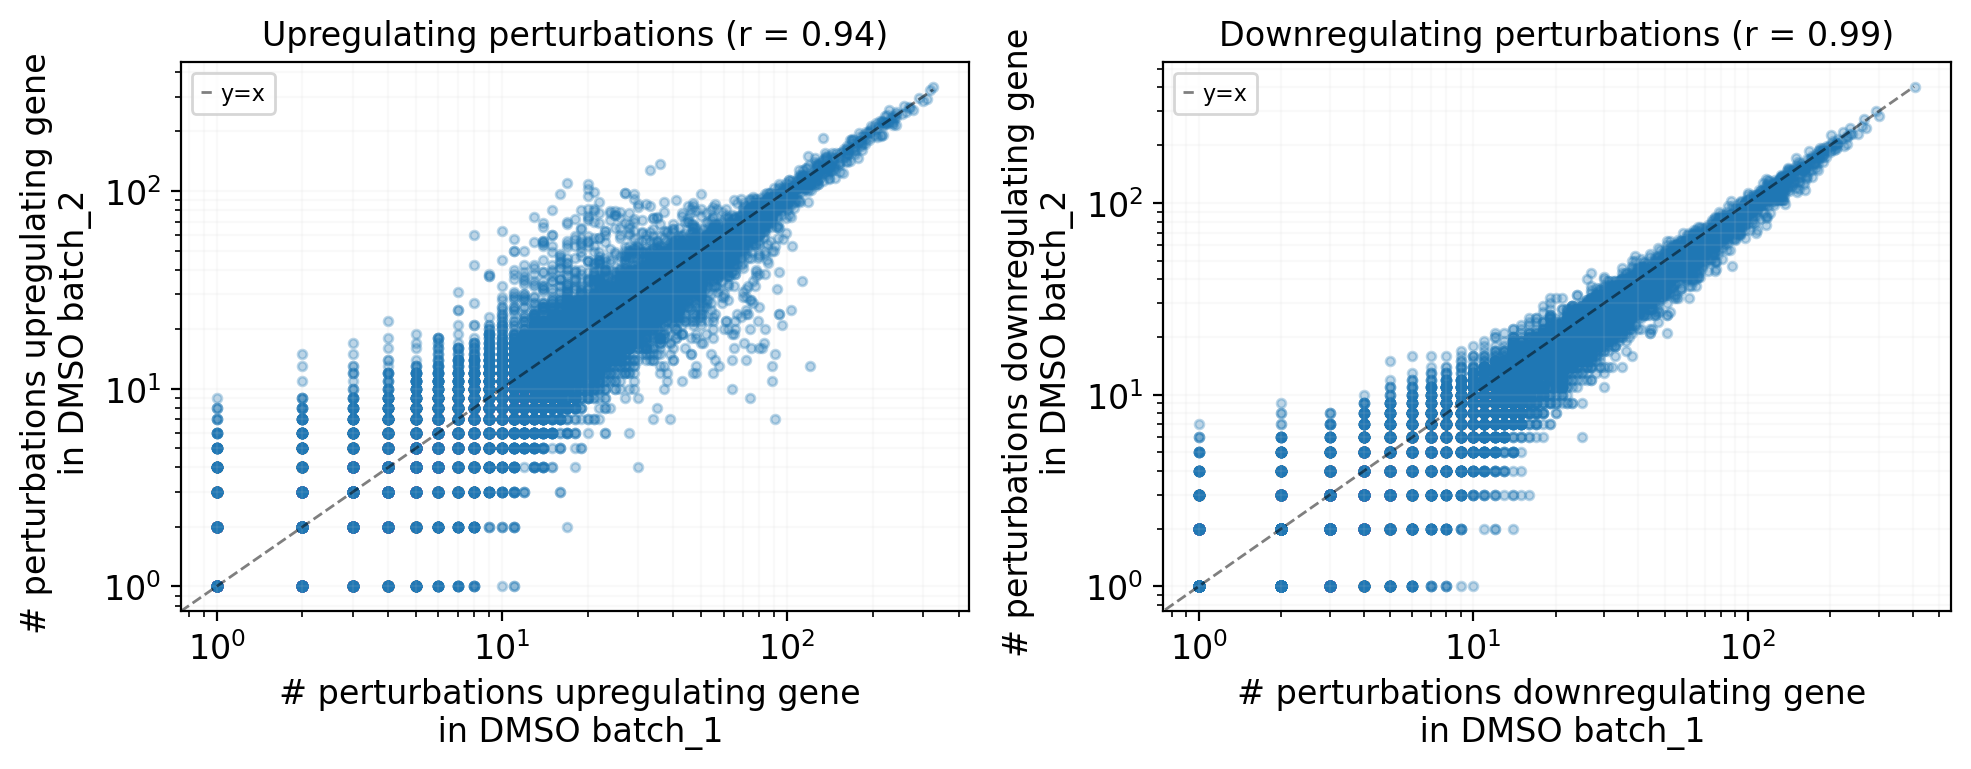

In [100]:
def colwise_jaccard_signed_and_counts(A, B):
    """
    Computes:
      - Jaccard for positive entries per column
      - Jaccard for negative entries per column
      - #up perturbations per column (gene) in A and B
      - #down perturbations per column (gene) in A and B
    A, B: numpy arrays of shape (n_rows, n_cols)
    Returns:
      pos_jacc: (n_cols,)
      neg_jacc: (n_cols,)
      n_up_A:   (n_cols,)
      n_up_B:   (n_cols,)
      n_down_A: (n_cols,)
      n_down_B: (n_cols,)
    """
    if A.shape != B.shape:
        raise ValueError(f"Shape mismatch: A{A.shape}, B{B.shape}")
    # Boolean masks
    A_pos = A > 0
    B_pos = B > 0
    A_neg = A < 0
    B_neg = B < 0
    # --- Positive Jaccard ---
    pos_inter = np.logical_and(A_pos, B_pos).sum(axis=0)  # Changed to axis=0
    pos_union = np.logical_or(A_pos, B_pos).sum(axis=0)   # Changed to axis=0
    pos_jacc = np.zeros(A.shape[1], dtype=float)          # Changed to A.shape[1]
    nonzero = pos_union != 0
    pos_jacc[nonzero] = pos_inter[nonzero] / pos_union[nonzero]
    # --- Negative Jaccard ---
    neg_inter = np.logical_and(A_neg, B_neg).sum(axis=0)  # Changed to axis=0
    neg_union = np.logical_or(A_neg, B_neg).sum(axis=0)   # Changed to axis=0
    neg_jacc = np.zeros(A.shape[1], dtype=float)          # Changed to A.shape[1]
    nonzero = neg_union != 0
    neg_jacc[nonzero] = neg_inter[nonzero] / neg_union[nonzero]
    # --- Counts of up / down perturbations per column ---
    n_up_A   = A_pos.sum(axis=0)   # Changed to axis=0
    n_up_B   = B_pos.sum(axis=0)   # Changed to axis=0
    n_down_A = A_neg.sum(axis=0)   # Changed to axis=0
    n_down_B = B_neg.sum(axis=0)   # Changed to axis=0
    return pos_jacc, neg_jacc, n_up_A, n_up_B, n_down_A, n_down_B

# -------------------------------------------------------
# Example usage with your matrices A and B
# -------------------------------------------------------
# A, B: (n_rows, n_cols) numpy arrays
pos_jacc, neg_jacc, n_up_A, n_up_B, n_down_A, n_down_B = colwise_jaccard_signed_and_counts(dmso_fc_zeroed, dmso_round2_fc_zeroed)

# Remove NaNs (columns with no union) for Jaccard plots
pos_vals = pos_jacc[~np.isnan(pos_jacc)]
neg_vals = neg_jacc[~np.isnan(neg_jacc)]

# ----------------- Histograms of Jaccard -----------------
plt.figure(figsize=(10, 4))
# Positive Jaccard
plt.subplot(1, 2, 1)
plt.hist(pos_vals, bins=50)
plt.title("Jaccard Similarity for upregulated perturbation conditions")
plt.xlabel("Jaccard")
plt.ylabel("Number of genes")
plt.grid(alpha=0.1)
# Negative Jaccard
plt.subplot(1, 2, 2)
plt.hist(neg_vals, bins=50)
plt.title("Jaccard Similarity for downregulated perturbation conditions")
plt.xlabel("Jaccard similarity")
plt.ylabel("Number of genes")
plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()

# ----------------- Scatterplots: up/down counts -----------------
# Pearson correlations
corr_up   = np.corrcoef(n_up_A,   n_up_B)[0, 1]
corr_down = np.corrcoef(n_down_A, n_down_B)[0, 1]
print(f"Correlation of #up perturbations per gene between A and B:   r = {corr_up:.3f}")
print(f"Correlation of #down perturbations per gene between A and B: r = {corr_down:.3f}")

plt.figure(figsize=(10, 4))

# Up perturbations
plt.subplot(1, 2, 1)
plt.scatter(n_up_A, n_up_B, s=10, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

# Add diagonal line (y=x)
lim_up = [max(n_up_A.min(), n_up_B.min()), min(n_up_A.max(), n_up_B.max())]
plt.plot(lim_up, lim_up, 'k--', alpha=0.5, linewidth=1, label='y=x')

plt.xlabel("# perturbations upregulating gene \n in DMSO batch_1")
plt.ylabel("# perturbations upregulating gene \n in DMSO batch_2")
plt.title(f"Upregulating perturbations (r = {corr_up:.2f})")
plt.grid(alpha=0.1, which='both')
plt.legend(loc='best', fontsize=8)

# Down perturbations
plt.subplot(1, 2, 2)
plt.scatter(n_down_A, n_down_B, s=10, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

# Add diagonal line (y=x)
lim_down = [max(n_down_A.min(), n_down_B.min()), min(n_down_A.max(), n_down_B.max())]
plt.plot(lim_down, lim_down, 'k--', alpha=0.5, linewidth=1, label='y=x')

plt.xlabel("# perturbations downregulating gene \n in DMSO batch_1")
plt.ylabel("# perturbations downregulating gene \n in DMSO batch_2")
plt.title(f"Downregulating perturbations (r = {corr_down:.2f})")
plt.grid(alpha=0.1, which='both')
plt.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

## Unsigned Jaccard — DMSO replicate concordance on *significantly-changing* genes

Same idea as the up/down split above, but collapsed: a gene is treated as a hit
in a given perturbation context if its `FDR < 0.01` (any direction). For each
perturbation we then compute Jaccard between the two replicate sets of
significantly-changing genes — and similarly per gene, the Jaccard of the
perturbation set that significantly affects it.


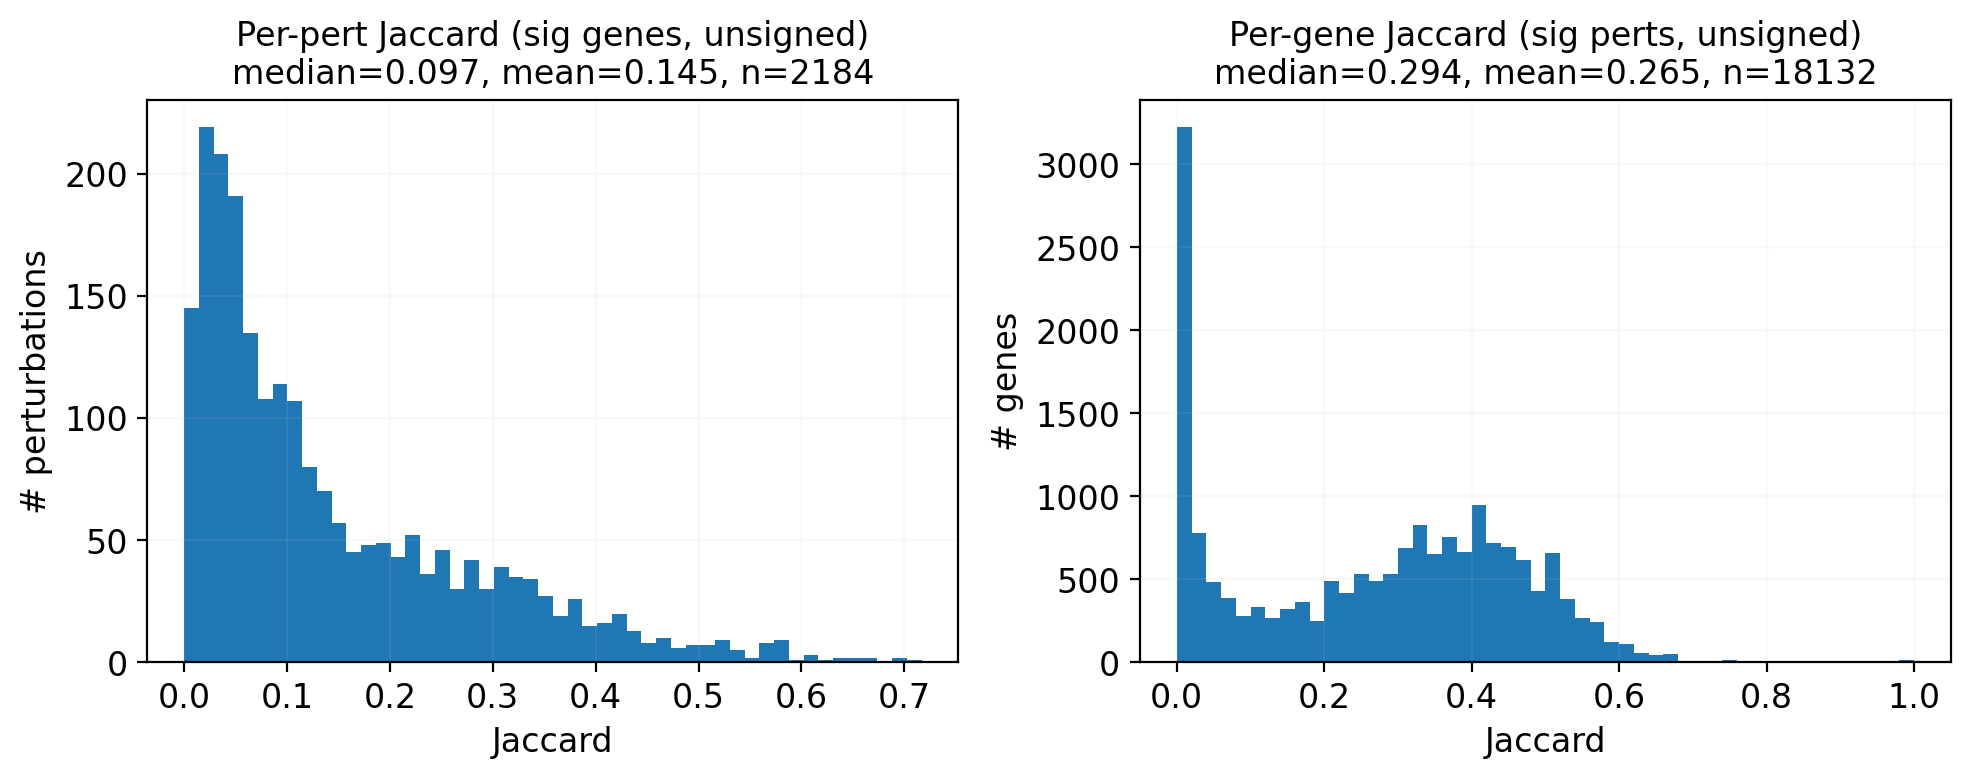

In [101]:
def rowwise_jaccard_unsigned(A, B):
    """
    Per-row Jaccard with NO sign separation: any non-zero entry counts as a hit.
    A, B: numpy arrays of shape (n_rows, n_cols).
    Returns:
      jacc:   (n_rows,) Jaccard similarity per row
      n_chg_A:(n_rows,) # changing entries per row in A
      n_chg_B:(n_rows,) # changing entries per row in B
    """
    if A.shape != B.shape:
        raise ValueError(f'Shape mismatch: A{A.shape}, B{B.shape}')
    A_chg = A != 0
    B_chg = B != 0
    inter = np.logical_and(A_chg, B_chg).sum(axis=1)
    union = np.logical_or(A_chg, B_chg).sum(axis=1)
    jacc  = np.full(A.shape[0], np.nan, dtype=float)
    nz    = union != 0
    jacc[nz] = inter[nz] / union[nz]
    return jacc, A_chg.sum(axis=1), B_chg.sum(axis=1)


def colwise_jaccard_unsigned(A, B):
    """Per-column variant of the same."""
    if A.shape != B.shape:
        raise ValueError(f'Shape mismatch: A{A.shape}, B{B.shape}')
    A_chg = A != 0
    B_chg = B != 0
    inter = np.logical_and(A_chg, B_chg).sum(axis=0)
    union = np.logical_or(A_chg, B_chg).sum(axis=0)
    jacc  = np.full(A.shape[1], np.nan, dtype=float)
    nz    = union != 0
    jacc[nz] = inter[nz] / union[nz]
    return jacc, A_chg.sum(axis=0), B_chg.sum(axis=0)


# ---- per perturbation: Jaccard of changing-gene sets ------------------
jacc_pert, n_chg_A_pert, n_chg_B_pert = rowwise_jaccard_unsigned(
    dmso_fc_zeroed.values, dmso_round2_fc_zeroed.values)

# ---- per gene: Jaccard of perturbation sets that change it ------------
jacc_gene, n_chg_A_gene, n_chg_B_gene = colwise_jaccard_unsigned(
    dmso_fc_zeroed.values, dmso_round2_fc_zeroed.values)

vals_pert = jacc_pert[~np.isnan(jacc_pert)]
vals_gene = jacc_gene[~np.isnan(jacc_gene)]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(vals_pert, bins=50)
plt.title('Per-pert Jaccard (sig genes, unsigned)\n'
          f'median={np.median(vals_pert):.3f}, mean={vals_pert.mean():.3f}, n={len(vals_pert)}')
plt.xlabel('Jaccard'); plt.ylabel('# perturbations')
plt.grid(alpha=0.1)

plt.subplot(1, 2, 2)
plt.hist(vals_gene, bins=50)
plt.title('Per-gene Jaccard (sig perts, unsigned)\n'
          f'median={np.median(vals_gene):.3f}, mean={vals_gene.mean():.3f}, n={len(vals_gene)}')
plt.xlabel('Jaccard'); plt.ylabel('# genes')
plt.grid(alpha=0.1)
plt.tight_layout(); plt.show()


In [102]:
dmso_fc_zeroed.shape

(2184, 18154)

In [103]:
from sklearn.metrics.pairwise import cosine_similarity
def rowwise_cosine_sim(A, B):
    cos_sim = np.array([
        cosine_similarity(A[i:i+1], B[i:i+1])[0,0]
        for i in range(A.shape[0])
    ])
    return cos_sim


In [104]:
cosineSim = rowwise_cosine_sim(dmso_fc, dmso_round2_fc)

In [105]:
cosineSim_genes = rowwise_cosine_sim(np.transpose(dmso_fc), np.transpose(dmso_round2_fc))

In [106]:
def rowwise_pearson_df(A, B, method='pearson'):
    # If DataFrames, convert to numpy
    if isinstance(A, pd.DataFrame):
        A = A.to_numpy()
    if isinstance(B, pd.DataFrame):
        B = B.to_numpy()

    if A.shape != B.shape:
        raise ValueError(f"Shape mismatch: A{A.shape}, B{B.shape}")

    if method == 'pearson':
        r = np.array([
            pearsonr(A[i], B[i])[0] if np.std(A[i]) > 0 and np.std(B[i]) > 0 else np.nan
            for i in range(A.shape[0])
        ])
    elif method == 'spearman':
        r = np.array([
                    spearmanr(A[i], B[i]).correlation
                    if np.std(A[i]) > 0 and np.std(B[i]) > 0
                    else np.nan
                    for i in range(A.shape[0])])
    return r



In [107]:
pearson_r = rowwise_pearson_df(dmso_fc, dmso_round2_fc, method="pearson")
spearman_r = rowwise_pearson_df(dmso_fc, dmso_round2_fc, method="spearman")


In [108]:
pearson_r_genes = rowwise_pearson_df(np.transpose(dmso_fc), np.transpose(dmso_round2_fc), method='pearson')
spearman_r_genes = rowwise_pearson_df(np.transpose(dmso_fc), np.transpose(dmso_round2_fc), method='spearman')

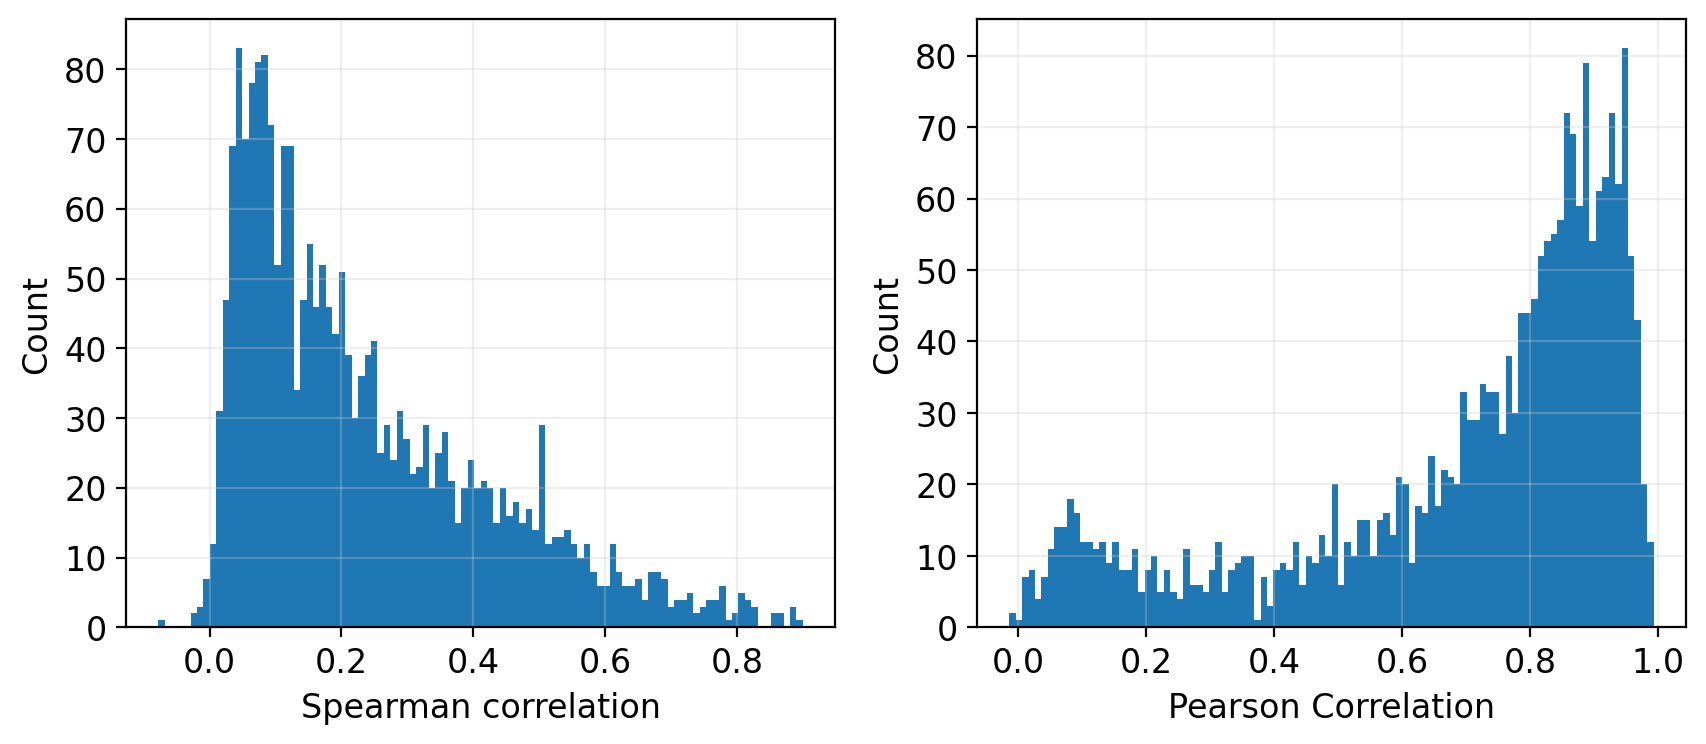

In [109]:
def drop_nan(x):
    return x[~np.isnan(x)]

# Cosine distance
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(drop_nan(spearman_r), bins=100)
#plt.title("Cosine Similarity")
plt.xlabel("Spearman correlation")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
#plt.xlim(0,0.3)

# Pearson correlation
plt.subplot(1, 2, 2)
plt.hist(drop_nan(pearson_r), bins=100)
plt.xlabel("Pearson Correlation")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
#plt.xlim(0,0.3)
plt.show()


In [110]:
np.median(spearman_r_genes)

np.float64(nan)

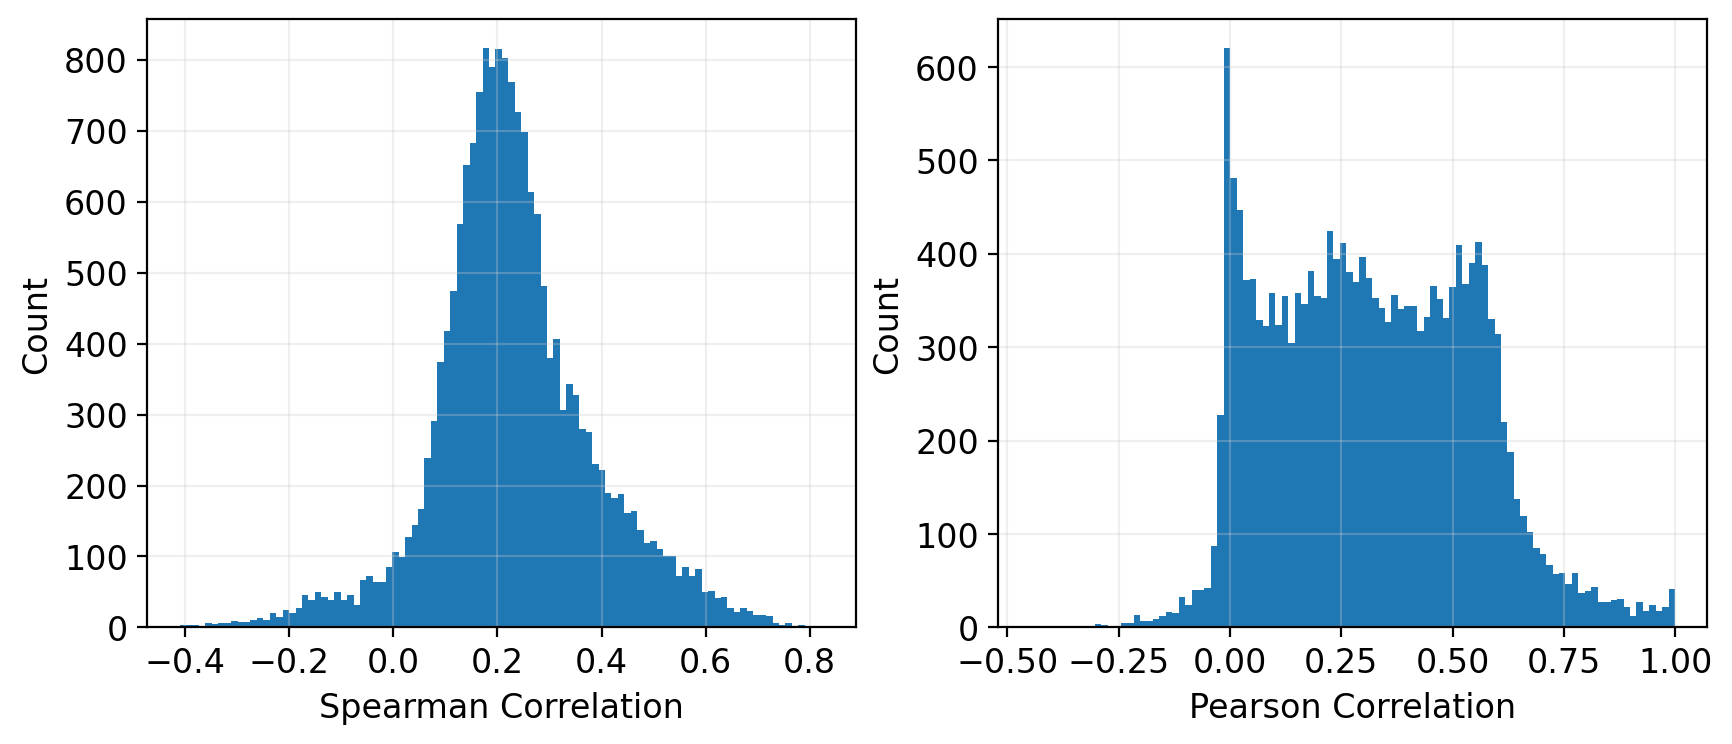

In [111]:
def drop_nan(x):
    return x[~np.isnan(x)]

# Cosine distance
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(drop_nan(spearman_r_genes), bins=100)
#plt.title("Cosine Similarity")
plt.xlabel("Spearman Correlation")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
#plt.xlim(0,0.3)

# Pearson correlation
plt.subplot(1, 2, 2)
plt.hist(drop_nan(pearson_r_genes), bins=100)
plt.xlabel("Pearson Correlation")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
#plt.xlim(0,0.3)
plt.show()

In [112]:

# X, Y: genes × perturbations (as before)
X = np.transpose(dmso_fc)
Y = np.transpose(dmso_round2_fc)
# X = dmso_fc
# Y = dmso_round2_fc

max_pcs = 250

# --- PCA on X ---
pca = PCA(n_components=max_pcs)
PCs = pca.fit_transform(X)
var_explained_per_PC = pca.explained_variance_ratio_

# --- Precompute total variance in Y ---
SS_total_Y = ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
SS_total_Y_sum = SS_total_Y.sum()

# --- Sample 20 PC counts ---
np.random.seed(0)
k_values = np.unique(np.random.choice(np.arange(1, max_pcs + 1), size=20, replace=False))
k_values.sort()

var_X_cumulative = []
var_Y_explained = []

for k in k_values:
    PCs_k = PCs[:, :k]

    reg = LinearRegression().fit(PCs_k, Y)
    Y_pred_k = reg.predict(PCs_k)

    SS_resid_Y_k = ((Y - Y_pred_k) ** 2).sum(axis=0)
    R2_total_Y_k = 1.0 - SS_resid_Y_k.sum() / SS_total_Y_sum

    var_X_cumulative.append(var_explained_per_PC[:k].sum())
    var_Y_explained.append(R2_total_Y_k)

var_X_cumulative = np.array(var_X_cumulative)
var_Y_explained = np.array(var_Y_explained)

# --- Correlation ---
corr = np.corrcoef(var_X_cumulative, var_Y_explained)[0, 1]
print(f"Correlation between variance explained in X and Y: {corr:.3f}")


Correlation between variance explained in X and Y: 0.996


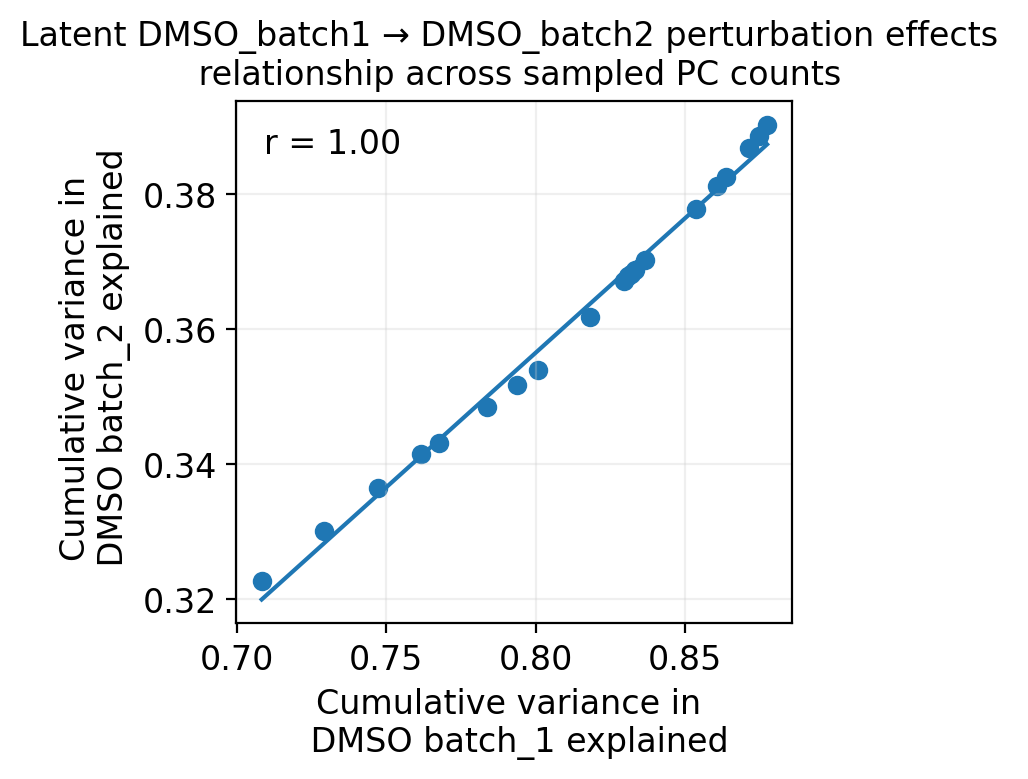

In [113]:
# --- Plot scatter + trend line ---
plt.figure(figsize=(4, 4))

plt.scatter(var_X_cumulative, var_Y_explained)

# trend line
coef = np.polyfit(var_X_cumulative, var_Y_explained, 1)
x_line = np.linspace(var_X_cumulative.min(), var_X_cumulative.max(), 100)
y_line = coef[0] * x_line + coef[1]
plt.plot(x_line, y_line)

plt.xlabel("Cumulative variance in \n DMSO batch_1 explained")
plt.ylabel("Cumulative variance in \n DMSO batch_2 explained")
plt.title("Latent DMSO_batch1 → DMSO_batch2 perturbation effects \n relationship across sampled PC counts")
plt.grid(True, alpha=0.3)

plt.text(0.05, 0.95, f"r = {corr:.2f}", transform=plt.gca().transAxes, va="top")

plt.tight_layout()
plt.show()


In [114]:
sum(dmso_fc_zeroed.index == dmso_round2_fc_zeroed.index)

np.int64(2184)

In [115]:
sum(dmso_fc_zeroed.columns == dmso_round2_fc_zeroed.columns)

np.int64(18154)

In [116]:
np.median(neg_vals)

np.float64(0.2727272727272727)

In [117]:
np.median(pos_vals)

np.float64(0.25)

In [118]:
def _overlap_from_two_mats(
    X_df: pd.DataFrame,
    Y_df: pd.DataFrame,
    *,
    sel_perts: list[str] | pd.Index | None = None,
    sel_genes: list[str] | pd.Index | None = None,
    k: int = 200,
    axis: str = "rows",   # "rows" or "cols"
    center: str = "cols", # "cols" or "rows" or "none"
    min_common_rows: int = 50,
    min_common_cols: int = 50,
) -> float:
    # ---- optional pre-filtering to user-selected sets ----
    if sel_perts is not None:
        sel_perts = pd.Index(sel_perts)
        X_df = X_df.loc[X_df.index.intersection(sel_perts)]
        Y_df = Y_df.loc[Y_df.index.intersection(sel_perts)]

    if sel_genes is not None:
        sel_genes = pd.Index(sel_genes)
        X_df = X_df.loc[:, X_df.columns.intersection(sel_genes)]
        Y_df = Y_df.loc[:, Y_df.columns.intersection(sel_genes)]

    # ---- align pair on intersection ----
    common_rows = X_df.index.intersection(Y_df.index)
    common_cols = X_df.columns.intersection(Y_df.columns)

    if len(common_rows) < min_common_rows:
        raise ValueError(f"Too few common rows after filtering: {len(common_rows)} (<{min_common_rows}).")
    if len(common_cols) < min_common_cols:
        raise ValueError(f"Too few common cols after filtering: {len(common_cols)} (<{min_common_cols}).")

    X = X_df.loc[common_rows, common_cols].to_numpy(dtype=np.float64, copy=False)
    Y = Y_df.loc[common_rows, common_cols].to_numpy(dtype=np.float64, copy=False)

    # ---- centering ----
    if center == "cols":
        X = X - X.mean(axis=0, keepdims=True)
        Y = Y - Y.mean(axis=0, keepdims=True)
    elif center == "rows":
        X = X - X.mean(axis=1, keepdims=True)
        Y = Y - Y.mean(axis=1, keepdims=True)
    elif center == "none":
        pass
    else:
        raise ValueError("center must be 'cols', 'rows', or 'none'")

    # ---- SVDs ----
    U1, _, Vt1 = np.linalg.svd(X, full_matrices=False)
    U2, _, Vt2 = np.linalg.svd(Y, full_matrices=False)

    if axis == "rows":
        k_eff = min(k, U1.shape[1], U2.shape[1])
        Q1 = U1[:, :k_eff]
        Q2 = U2[:, :k_eff]
    elif axis == "cols":
        k_eff = min(k, Vt1.shape[0], Vt2.shape[0])
        Q1 = Vt1.T[:, :k_eff]
        Q2 = Vt2.T[:, :k_eff]
    else:
        raise ValueError("axis must be 'rows' or 'cols'")

    # ---- principal-angle singular values ----
    M = Q1.T @ Q2
    sigmas = np.linalg.svd(M, compute_uv=False)
    sigmas = np.clip(sigmas[:k_eff], 0.0, 1.0)

    
    return float(np.mean(sigmas ** 2))
    


In [119]:
ov_r = _overlap_from_two_mats(
               dmso_fc, dmso_round2_fc,
                k=250, axis="rows")
ov_r

0.8486587181444174

In [120]:
ov_r = _overlap_from_two_mats(
               dmso_fc, dmso_round2_fc,
                k=250, axis="cols")
ov_r

0.27730298104224615

In [121]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
X1=dmso_fc
X2=dmso_round2_fc
def to_numpy(X):
    import pandas as pd
    if isinstance(X, pd.DataFrame):
        return X.to_numpy(), np.array(X.index)
    else:
        return np.asarray(X), np.arange(X.shape[0])

def compute_similarity_matrix(X):
    # rows = perturbations
    return cosine_similarity(X)  # shape (n_perts, n_perts)

X1_arr, pert_names1 = to_numpy(X1)
X2_arr, pert_names2 = to_numpy(X2)

assert X1_arr.shape == X2_arr.shape
assert np.all(pert_names1 == pert_names2)

S1 = compute_similarity_matrix(X1_arr)
S2 = compute_similarity_matrix(X2_arr)


In [122]:
import pandas as pd

def knn_indices(S, k):
    """
    S: (n_perts, n_perts) similarity matrix
    returns: list of arrays, each of length k with neighbor indices
    """
    n = S.shape[0]
    knn = []
    for i in range(n):
        # argsort descending, drop self
        idx_sorted = np.argsort(-S[i, :])
        idx_sorted = idx_sorted[idx_sorted != i]
        knn.append(idx_sorted[:k])
    return knn

def jaccard(a, b):
    sa, sb = set(a), set(b)
    if not sa and not sb:
        return np.nan
    inter = len(sa & sb)
    union = len(sa | sb)
    return inter / union if union > 0 else np.nan

def compare_neighborhoods(S1, S2, pert_names, k=10):
    knn1 = knn_indices(S1, k)
    knn2 = knn_indices(S2, k)

    n = S1.shape[0]
    jaccs = np.zeros(n)
    for i in range(n):
        jaccs[i] = jaccard(knn1[i], knn2[i])

    return pd.DataFrame({
        "perturbation": pert_names,
        f"knn_jaccard_k{k}": jaccs
    }).set_index("perturbation")

neigh_df = compare_neighborhoods(S1, S2, pert_names1, k=30)
print(neigh_df.head())
print("Median k-NN Jaccard:", np.nanmedian(neigh_df.iloc[:, 0]))


              knn_jaccard_k30
perturbation                 
A1BG                 0.333333
AASS                 0.500000
ABCB6                0.363636
ABCC5                0.132075
ABCF1                0.052632
Median k-NN Jaccard: 0.30434782608695654


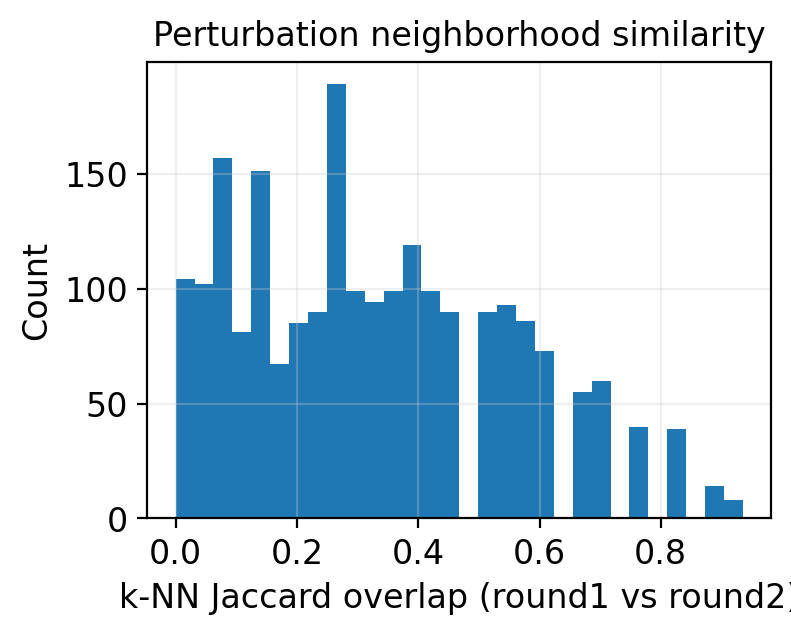

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.hist(neigh_df.iloc[:, 0].dropna(), bins=30)
plt.xlabel("k-NN Jaccard overlap (round1 vs round2)")
plt.ylabel("Count")
plt.title("Perturbation neighborhood similarity")
plt.grid(True, alpha=0.3)
plt.show()


# Pathway-level concordance between DMSO replicates from OLS

Now use the OLS results on the 134 representative KEGG pathways:

`pathway_score ~ C(target_gene)`, non-targeting as reference,
with `beta_<drug>.parquet` and `fdr_<drug>.parquet` per (perturbation, pathway).

**Filters** (applied in order, both at FDR < 0.10):

1. **Pathway filter** — keep pathways with ≥20 perturbations significant in *either* replicate
   (drops pathways with too few hits to support a meaningful Jaccard).
2. **Perturbation filter** — keep perturbations hitting ≥3 of those kept pathways in *either*
   replicate (drops weakly-acting KOs whose Jaccard is dominated by 0–1 hits).

For each surviving perturbation we then compute Jaccard between the two replicate sets of
significantly-affected pathways:

1. **Unsigned**  — any pathway with `FDR<0.1` counts as a hit.
2. **Signed**    — separate Jaccard for `β>0` (induced) and `β<0` (suppressed) pathways.


In [124]:
from pathlib import Path

OLS_DIR = Path('/home/beraslan/Projects/ChemoGeneticScreens/PertPathwayOLS')

beta_A = pd.read_parquet(OLS_DIR / 'beta_DMSO_round2.parquet')
fdr_A  = pd.read_parquet(OLS_DIR / 'fdr_DMSO_round2.parquet')
beta_B = pd.read_parquet(OLS_DIR / 'beta_DMSO_round2_batch2.parquet')
fdr_B  = pd.read_parquet(OLS_DIR / 'fdr_DMSO_round2_batch2.parquet')

common_perts = beta_A.index.intersection(beta_B.index)
common_paths = beta_A.columns.intersection(beta_B.columns)
print(f'common perturbations: {len(common_perts)}')
print(f'common pathways:      {len(common_paths)}')

beta_A = beta_A.loc[common_perts, common_paths]
fdr_A  = fdr_A.loc[common_perts,  common_paths]
beta_B = beta_B.loc[common_perts, common_paths]
fdr_B  = fdr_B.loc[common_perts,  common_paths]

FDR_THR_FILT          = 0.01
MIN_PERTS_PER_PATHWAY = 20
MIN_PATHWAYS_PER_PERT = 3

# ----------------------------------------------------------------------
# Pathway filter — keep pathways with ≥MIN_PERTS_PER_PATHWAY sig perts in either replicate
# ----------------------------------------------------------------------
n_sig_perts_A = (fdr_A.values < FDR_THR_FILT).sum(axis=0)   # per pathway, in A
n_sig_perts_B = (fdr_B.values < FDR_THR_FILT).sum(axis=0)   # per pathway, in B
keep_path = (n_sig_perts_A >= MIN_PERTS_PER_PATHWAY) | (n_sig_perts_B >= MIN_PERTS_PER_PATHWAY)
kept_paths = common_paths[keep_path]
print(f'\npathway filter: ≥{MIN_PERTS_PER_PATHWAY} perts with FDR<{FDR_THR_FILT} in either replicate')
print(f'  kept: {keep_path.sum()} / {len(common_paths)} pathways')

beta_A = beta_A.loc[:, kept_paths]
fdr_A  = fdr_A.loc[:,  kept_paths]
beta_B = beta_B.loc[:, kept_paths]
fdr_B  = fdr_B.loc[:,  kept_paths]
common_paths = kept_paths

# ----------------------------------------------------------------------
# Perturbation filter — keep perts hitting ≥MIN_PATHWAYS_PER_PERT of the kept pathways
# (FDR<FDR_THR_FILT) in either replicate
# ----------------------------------------------------------------------
n_sig_paths_A = (fdr_A.values < FDR_THR_FILT).sum(axis=1)   # per pert, in A
n_sig_paths_B = (fdr_B.values < FDR_THR_FILT).sum(axis=1)   # per pert, in B
keep_pert = (n_sig_paths_A >= MIN_PATHWAYS_PER_PERT) | (n_sig_paths_B >= MIN_PATHWAYS_PER_PERT)
kept_perts = common_perts[keep_pert]
print(f'\nperturbation filter: ≥{MIN_PATHWAYS_PER_PERT} pathways with FDR<{FDR_THR_FILT} in either replicate')
print(f'  kept: {keep_pert.sum()} / {len(common_perts)} perturbations')
print(f'  in A only: {((n_sig_paths_A >= MIN_PATHWAYS_PER_PERT) & ~(n_sig_paths_B >= MIN_PATHWAYS_PER_PERT)).sum()}')
print(f'  in B only: {(~(n_sig_paths_A >= MIN_PATHWAYS_PER_PERT) & (n_sig_paths_B >= MIN_PATHWAYS_PER_PERT)).sum()}')
print(f'  in both:   {((n_sig_paths_A >= MIN_PATHWAYS_PER_PERT) & (n_sig_paths_B >= MIN_PATHWAYS_PER_PERT)).sum()}')

beta_A = beta_A.loc[kept_perts, :]
fdr_A  = fdr_A.loc[kept_perts,  :]
beta_B = beta_B.loc[kept_perts, :]
fdr_B  = fdr_B.loc[kept_perts,  :]
common_perts = kept_perts
print(f'\nfinal tensor: {len(common_perts)} perts × {len(common_paths)} pathways')


common perturbations: 931
common pathways:      134

pathway filter: ≥20 perts with FDR<0.01 in either replicate
  kept: 134 / 134 pathways

perturbation filter: ≥3 pathways with FDR<0.01 in either replicate
  kept: 888 / 931 perturbations
  in A only: 44
  in B only: 48
  in both:   796

final tensor: 888 perts × 134 pathways


## 1. Unsigned pathway Jaccard (FDR < 0.1)


perturbations with ≥1 sig pathway in either replicate: 888/888
median Jaccard = 0.500,  mean = 0.484


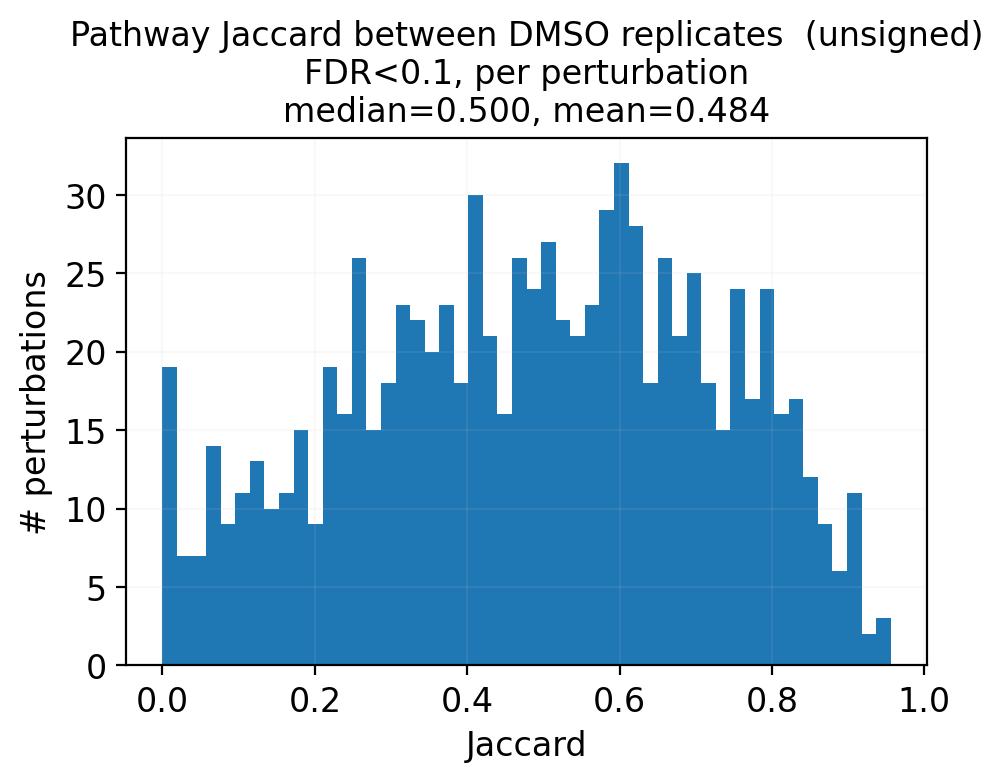

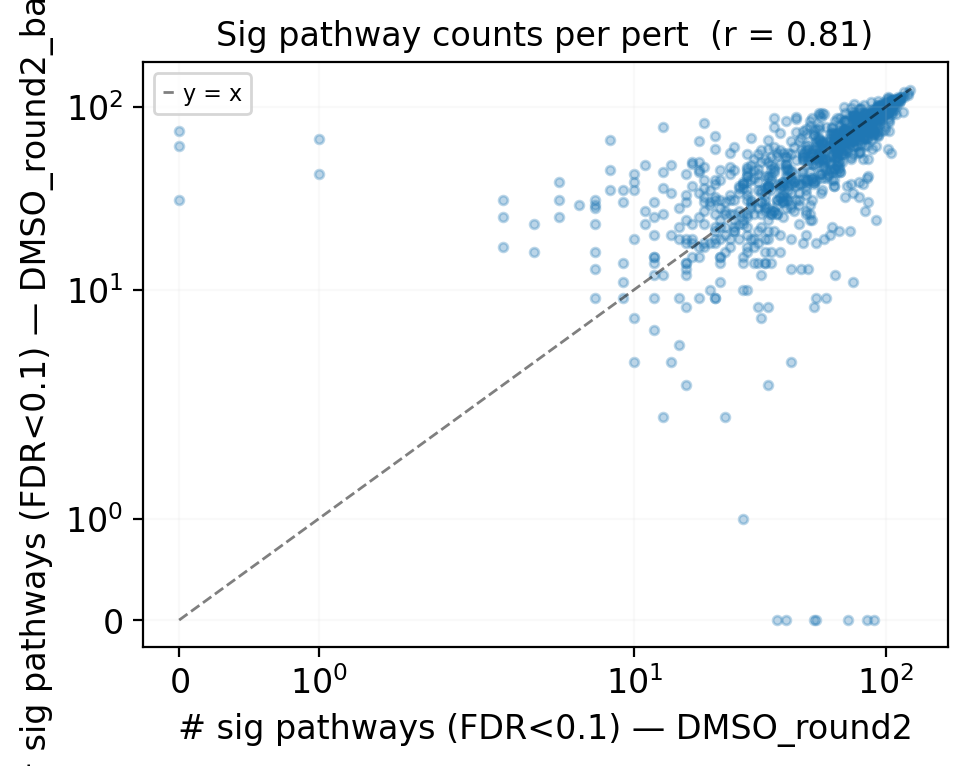

In [132]:
FDR_THR = 0.1

sig_A = (fdr_A < FDR_THR).values
sig_B = (fdr_B < FDR_THR).values

inter = np.logical_and(sig_A, sig_B).sum(axis=1)
union = np.logical_or(sig_A, sig_B).sum(axis=1)
jacc_path_unsigned = np.full(len(common_perts), np.nan, dtype=float)
nz = union > 0
jacc_path_unsigned[nz] = inter[nz] / union[nz]

vals = jacc_path_unsigned[~np.isnan(jacc_path_unsigned)]
print(f'perturbations with ≥1 sig pathway in either replicate: {len(vals)}/{len(common_perts)}')
print(f'median Jaccard = {np.median(vals):.3f},  mean = {vals.mean():.3f}')

# Histogram
plt.figure(figsize=(5, 4))
plt.hist(vals, bins=50)
plt.title(f'Pathway Jaccard between DMSO replicates  (unsigned)\n'
          f'FDR<{FDR_THR}, per perturbation\n'
          f'median={np.median(vals):.3f}, mean={vals.mean():.3f}')
plt.xlabel('Jaccard'); plt.ylabel('# perturbations')
plt.grid(alpha=0.1)
plt.tight_layout(); plt.show()

# Sanity: scatter of #sig pathways per pert across replicates
sig_count_A = sig_A.sum(axis=1)
sig_count_B = sig_B.sum(axis=1)
r_count = np.corrcoef(sig_count_A, sig_count_B)[0, 1]
plt.figure(figsize=(5, 4))
plt.scatter(sig_count_A, sig_count_B, s=10, alpha=0.3)
lim = [0, max(sig_count_A.max(), sig_count_B.max()) + 1]
plt.plot(lim, lim, 'k--', alpha=0.5, lw=1, label='y = x')
plt.xscale('symlog'); plt.yscale('symlog')
plt.xlabel('# sig pathways (FDR<0.1) — DMSO_round2')
plt.ylabel('# sig pathways (FDR<0.1) — DMSO_round2_batch2')
plt.title(f'Sig pathway counts per pert  (r = {r_count:.2f})')
plt.legend(loc='best', fontsize=8)
plt.grid(alpha=0.1, which='both')
plt.tight_layout(); plt.show()


## 2. Signed pathway Jaccard — split by direction of $\beta$

Separate Jaccards for *induced* ($\beta>0$, FDR<0.1) and *suppressed* ($\beta<0$, FDR<0.1)
pathways. A perturbation that pushes a pathway up in one replicate and down in the other
won't appear in the intersection of either set.


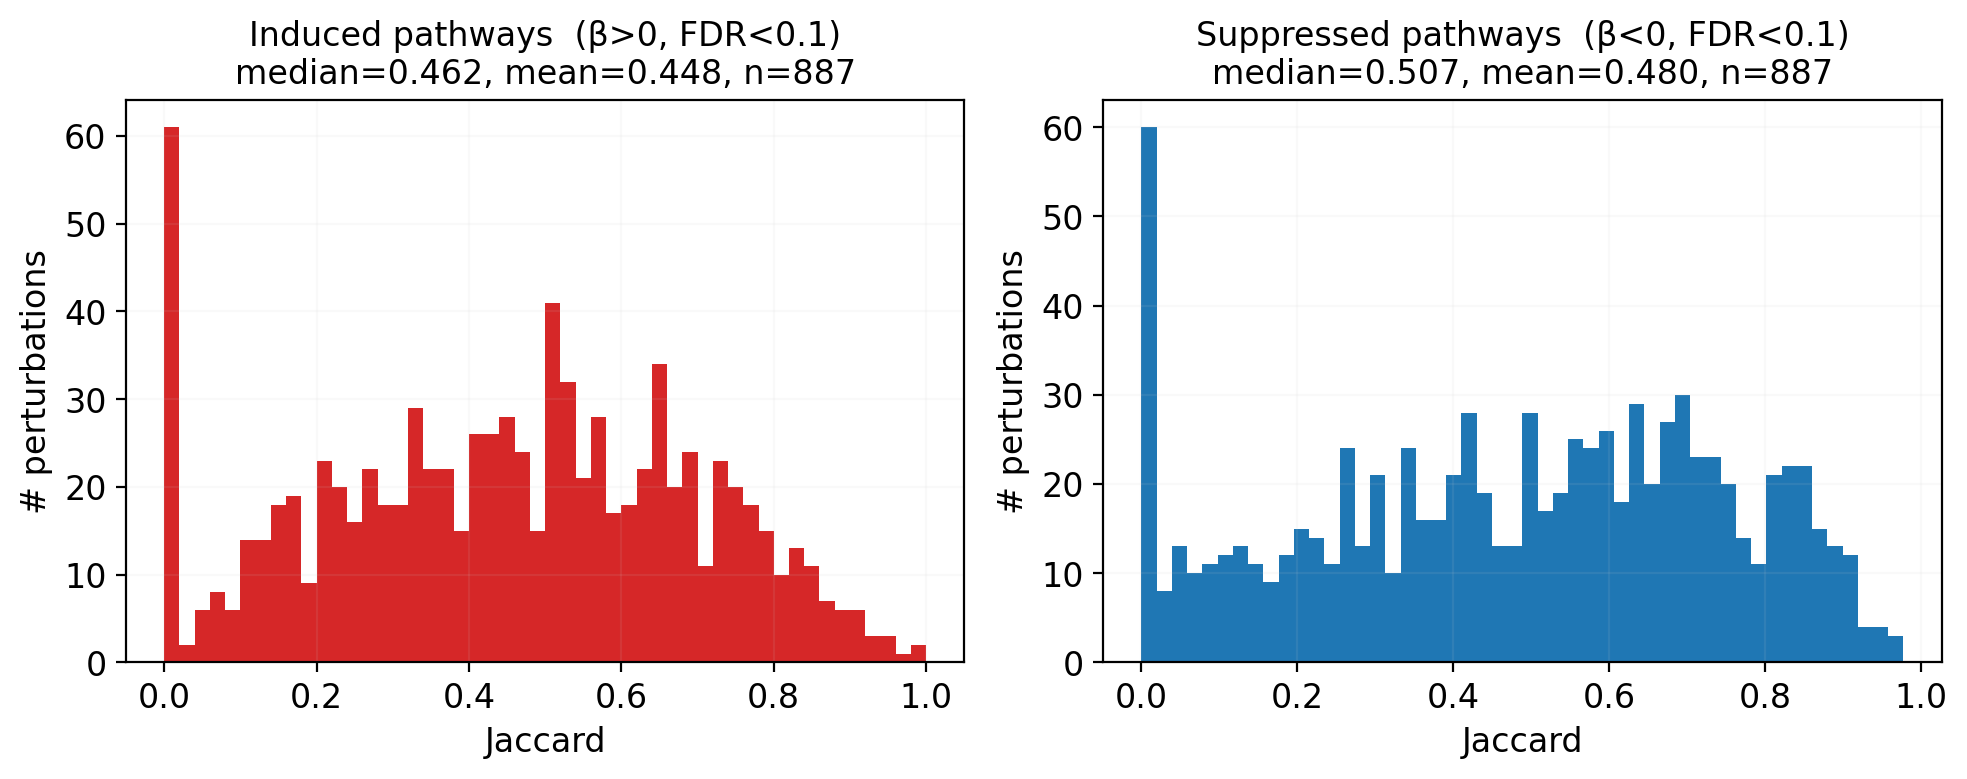

(pert × pathway) cells with FDR<0.1 in BOTH replicates: 35,488
  fraction agreeing on sign(β): 99.8%


In [130]:
FDR_THR = 0.1

sig_A = (fdr_A < FDR_THR).values
sig_B = (fdr_B < FDR_THR).values
betaA = beta_A.values
betaB = beta_B.values

up_A = sig_A & (betaA > 0)
up_B = sig_B & (betaB > 0)
dn_A = sig_A & (betaA < 0)
dn_B = sig_B & (betaB < 0)

def per_row_jaccard(A, B):
    inter = np.logical_and(A, B).sum(axis=1)
    union = np.logical_or(A, B).sum(axis=1)
    j = np.full(A.shape[0], np.nan, dtype=float)
    nz = union > 0
    j[nz] = inter[nz] / union[nz]
    return j

j_up = per_row_jaccard(up_A, up_B)
j_dn = per_row_jaccard(dn_A, dn_B)

vals_up = j_up[~np.isnan(j_up)]
vals_dn = j_dn[~np.isnan(j_dn)]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(vals_up, bins=50, color='C3')
plt.title(f'Induced pathways  (β>0, FDR<{FDR_THR})\n'
          f'median={np.median(vals_up):.3f}, mean={vals_up.mean():.3f}, n={len(vals_up)}')
plt.xlabel('Jaccard'); plt.ylabel('# perturbations'); plt.grid(alpha=0.1)

plt.subplot(1, 2, 2)
plt.hist(vals_dn, bins=50, color='C0')
plt.title(f'Suppressed pathways  (β<0, FDR<{FDR_THR})\n'
          f'median={np.median(vals_dn):.3f}, mean={vals_dn.mean():.3f}, n={len(vals_dn)}')
plt.xlabel('Jaccard'); plt.ylabel('# perturbations'); plt.grid(alpha=0.1)
plt.tight_layout(); plt.show()

# Sign-discordance check: for sig-in-both pairs, what fraction agree on sign?
sig_both = sig_A & sig_B
sign_match = sig_both & ((betaA > 0) == (betaB > 0))
frac_agree = sign_match.sum() / max(sig_both.sum(), 1)
print(f'(pert × pathway) cells with FDR<{FDR_THR} in BOTH replicates: {sig_both.sum():,}')
print(f'  fraction agreeing on sign(β): {frac_agree*100:.1f}%')


## 3. Side-by-side $\beta$ heatmaps (FDR-masked)

Visualise the filtered (perturbation × pathway) $\beta$ matrix for both DMSO replicates,
with a single shared row and column ordering computed by hierarchical clustering on the
FDR-masked average of the two matrices. Cells with `FDR ≥ 0.10` in a given replicate are
set to 0 in that replicate's panel and render white in the diverging colormap.

- **Red**   : β > 0 and FDR < 0.10 (perturbation *induces* the pathway)
- **White** : FDR ≥ 0.10 (not significant in this replicate)
- **Blue**  : β < 0 and FDR < 0.10 (perturbation *suppresses* the pathway)


symmetric vmax = 0.413  (99th percentile of |β| over sig cells)
shared ordering — 888 perts × 134 pathways


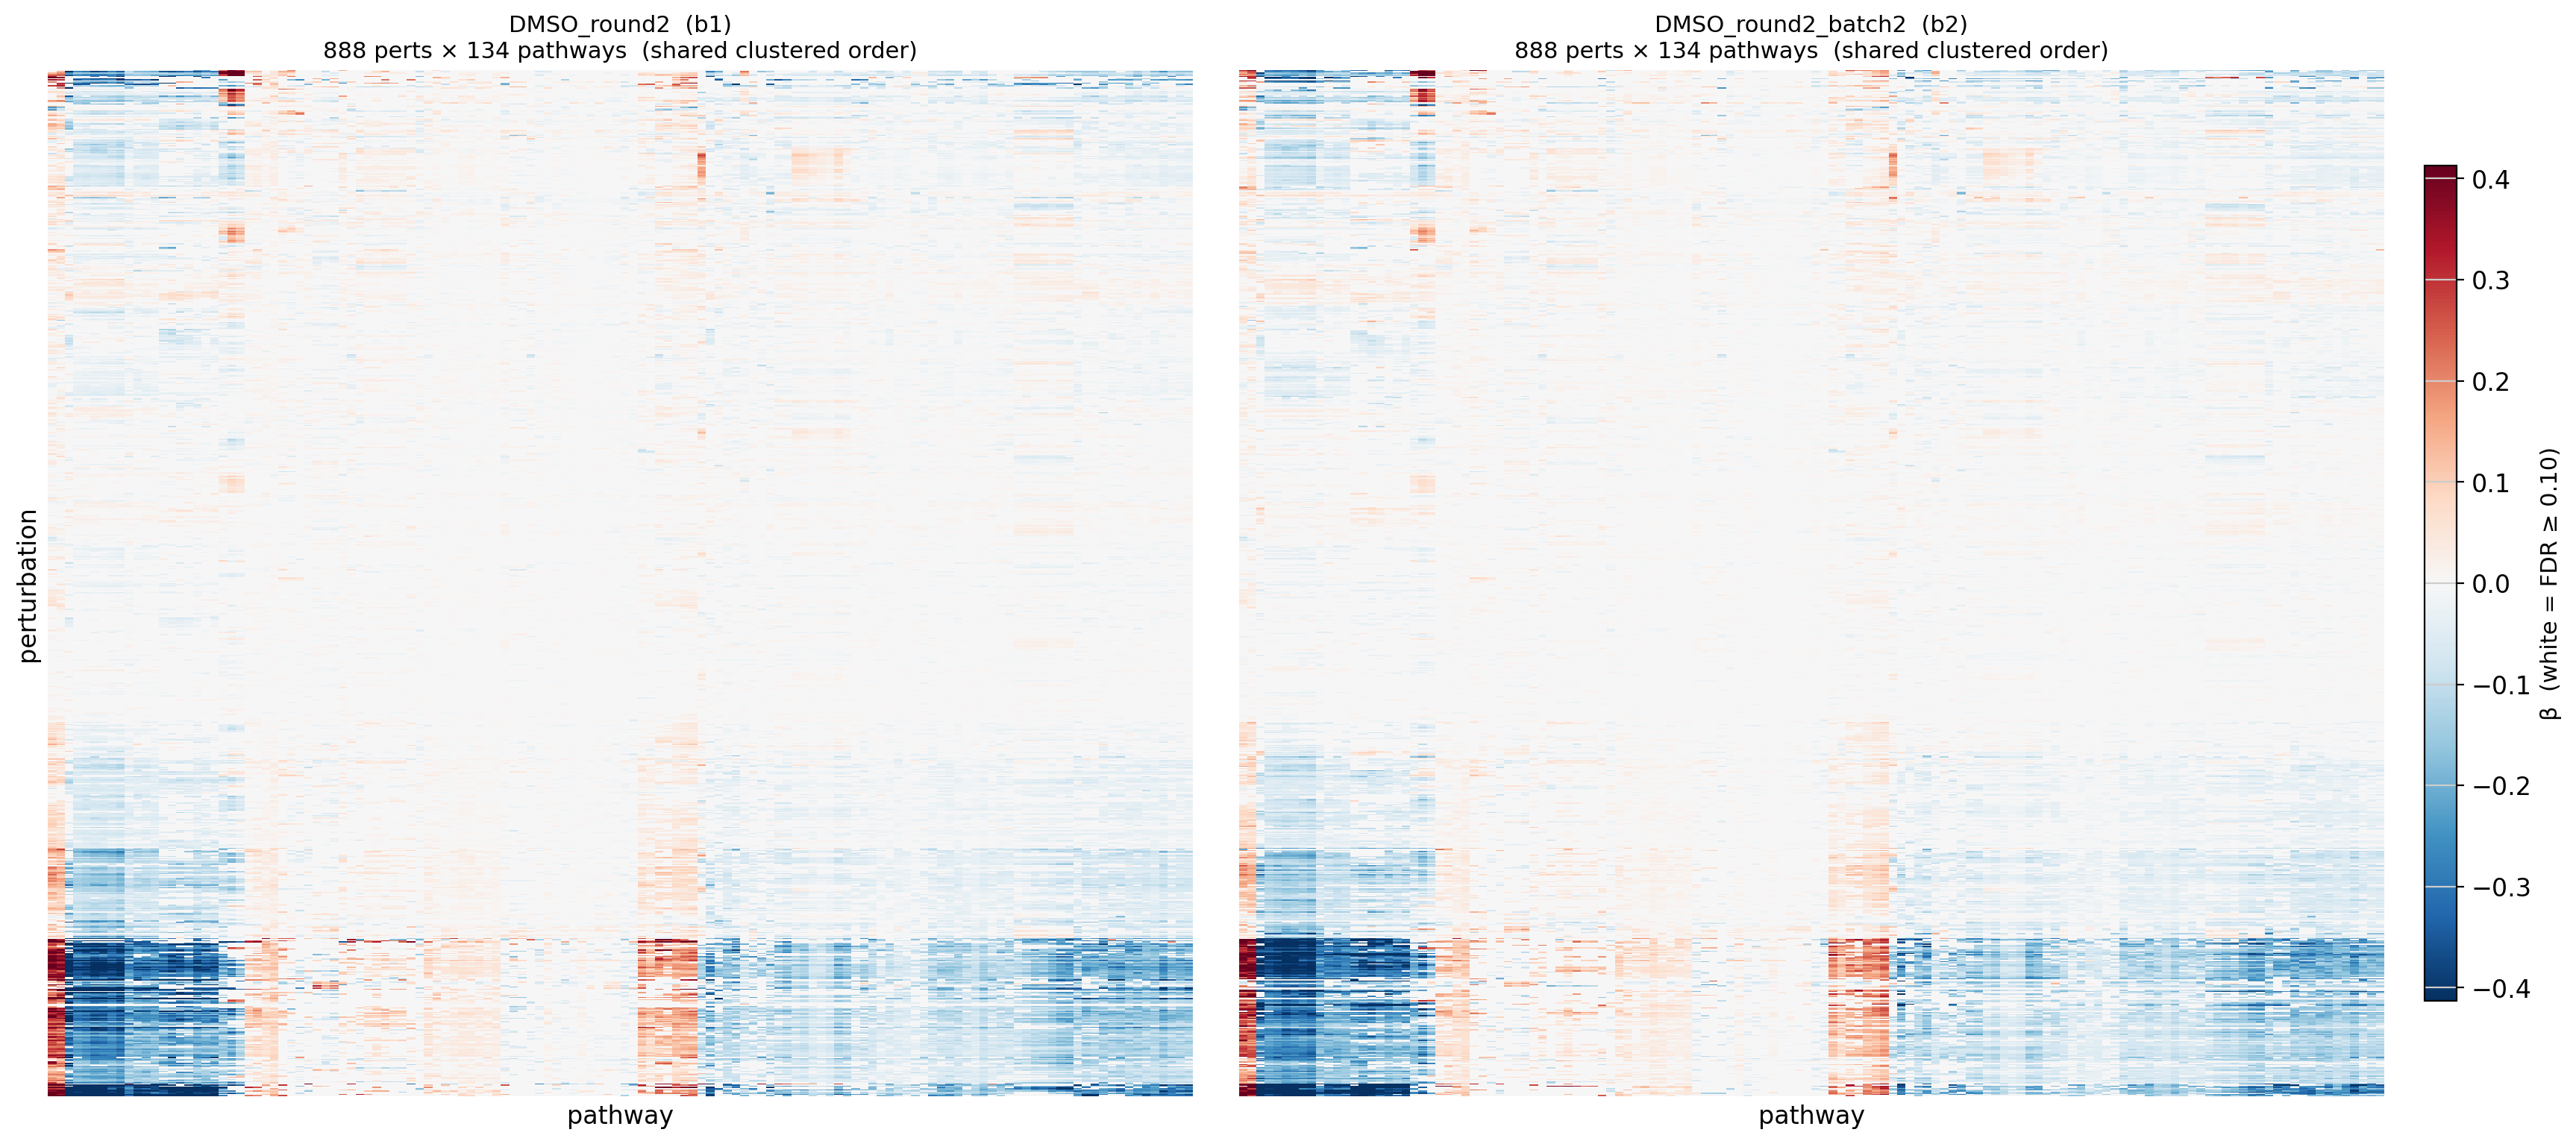

In [127]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

FDR_HM = 0.1                                  # significance mask used for the heatmap

# Mask non-significant cells to 0 (white in the diverging cmap).
# Treat NaN FDR as 'not significant' and NaN beta as 0 — keeps pdist finite for clustering.
fdrA_arr = np.where(np.isnan(fdr_A.values),  1.0, fdr_A.values)
fdrB_arr = np.where(np.isnan(fdr_B.values),  1.0, fdr_B.values)
mask_A = (fdrA_arr >= FDR_HM)
mask_B = (fdrB_arr >= FDR_HM)
betaA_disp = np.where(mask_A, 0.0, np.nan_to_num(beta_A.values, nan=0.0))
betaB_disp = np.where(mask_B, 0.0, np.nan_to_num(beta_B.values, nan=0.0))

# Shared row / column ordering: cluster on the average of the two masked matrices
beta_avg = (betaA_disp + betaB_disp) / 2.0

row_order = leaves_list(linkage(pdist(beta_avg,    metric='euclidean'), method='average'))
col_order = leaves_list(linkage(pdist(beta_avg.T,  metric='euclidean'), method='average'))

betaA_ord = betaA_disp[row_order][:, col_order]
betaB_ord = betaB_disp[row_order][:, col_order]
perts_ord = beta_A.index[row_order].tolist()
paths_ord = beta_A.columns[col_order].tolist()

# Symmetric color limit — robust to outliers (95th percentile of |β| of significant cells)
sig_vals = np.concatenate([betaA_disp[~mask_A], betaB_disp[~mask_B]])
vmax = float(np.quantile(np.abs(sig_vals), 0.99)) if sig_vals.size else 1.0
print(f'symmetric vmax = {vmax:.3f}  (99th percentile of |β| over sig cells)')
print(f'shared ordering — {betaA_ord.shape[0]} perts × {betaA_ord.shape[1]} pathways')

# Plot — single shared colorbar on the right
fig_h = max(6, 8)
fig, axes = plt.subplots(1, 2, figsize=(18, fig_h), sharey=True)

for ax, mat, title in [(axes[0], betaA_ord, 'DMSO_round2  (b1)'),
                        (axes[1], betaB_ord, 'DMSO_round2_batch2  (b2)')]:
    sns.heatmap(
        mat, ax=ax, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
        xticklabels=False, yticklabels=False,
        cbar=False,                                # disable per-panel cbars
    )
    ax.set_title(f'{title}\n{mat.shape[0]} perts × {mat.shape[1]} pathways  '
                  f'(shared clustered order)', fontsize=11)
    ax.set_xlabel('pathway')
axes[0].set_ylabel('perturbation')

# Single shared colorbar — sits to the right of the two panels
plt.subplots_adjust(left=0.05, right=0.92, top=0.93, bottom=0.07, wspace=0.04)
cbar_ax = fig.add_axes([0.935, 0.15, 0.012, 0.70])     # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap='RdBu_r',
                            norm=plt.Normalize(vmin=-vmax, vmax=vmax))
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('β  (white = FDR ≥ {:.2f})'.format(FDR_HM), fontsize=11)
plt.show()


## 4. Spearman correlation between replicates — per perturbation

For each perturbation in the filtered set, compute Spearman rank correlation between
the two DMSO replicates:

- **Gene-level**: across all common genes of `PosteriorMean_matrix_DMSO_round2.csv`
  and `PosteriorMean_matrix_DMSO_round2_batch2.csv`.
- **Pathway-level**: across the pathways kept by the OLS filter, on the per-(pert,pathway)
  $\beta$ values from `beta_<drug>.parquet`.

Both restricted to the same filtered perturbation set used by the Jaccard / heatmap
analyses above so the two histograms are directly comparable.


gene-level Spearman: 878 perts × 18154 genes
pathway-level Spearman: 878 perts × 134 pathways


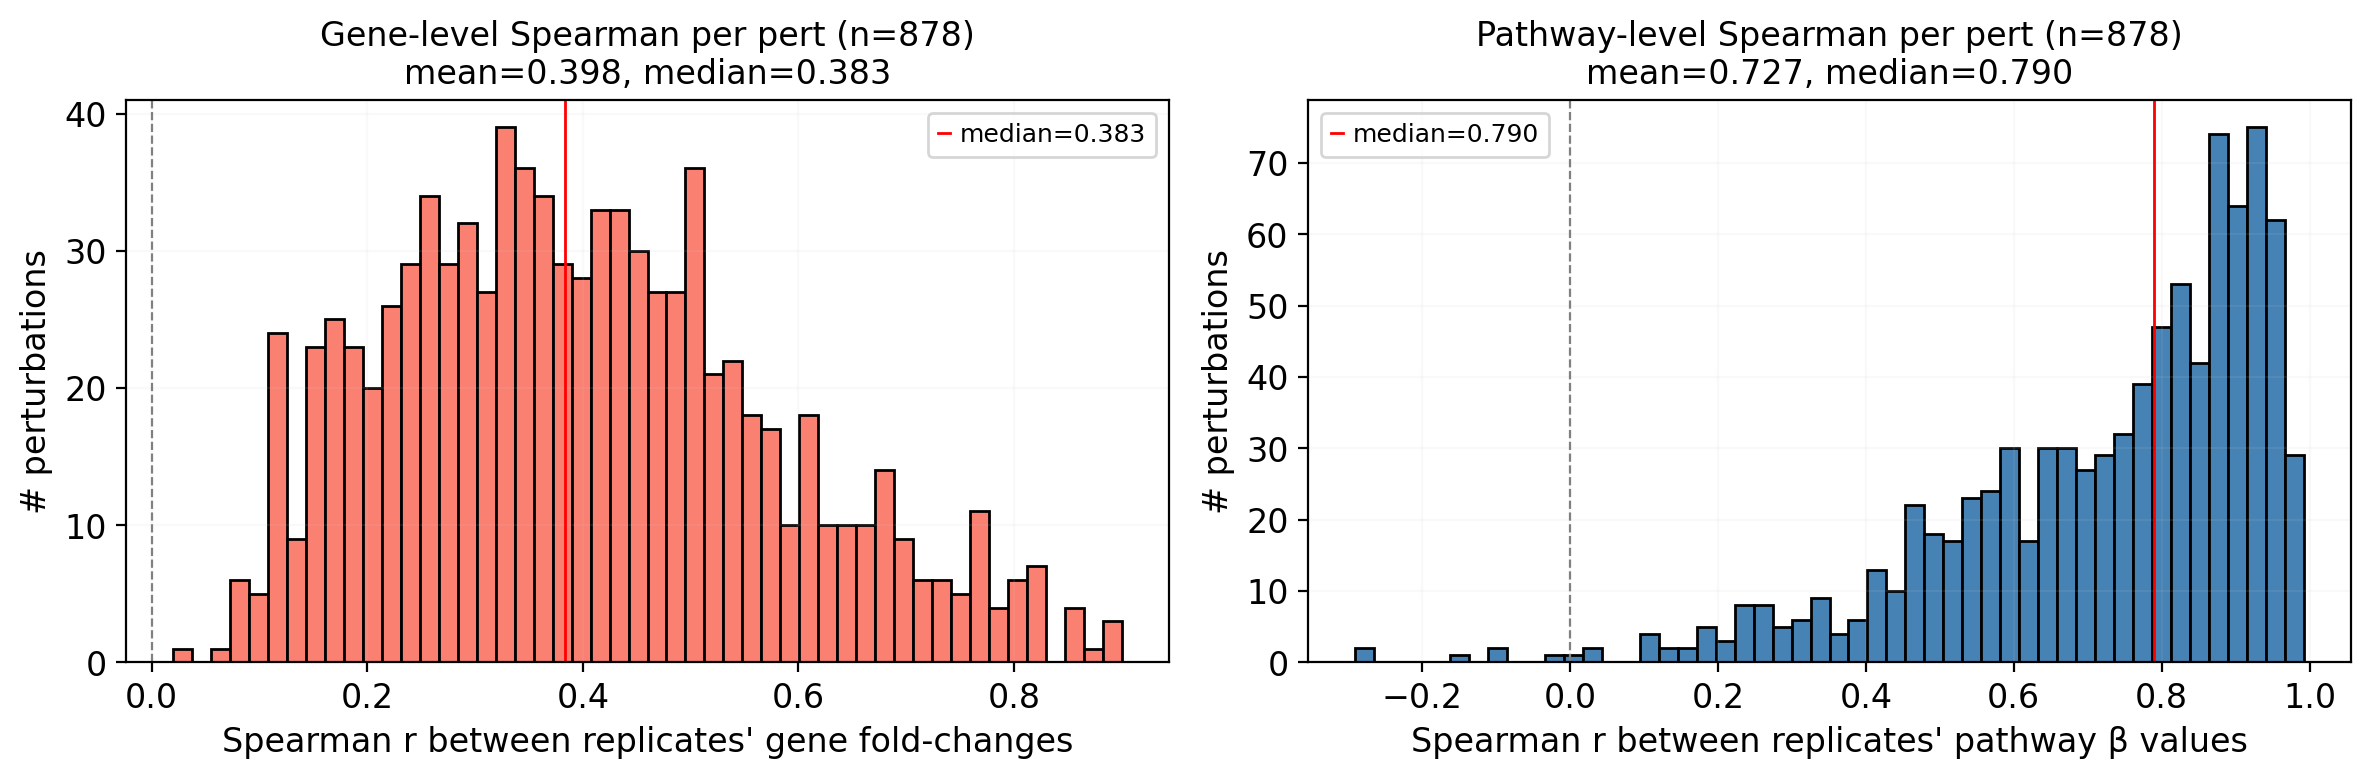

In [133]:
def rowwise_spearman(A, B):
    """Per-row Spearman: rank along axis=1, then Pearson on the ranks.
    A, B: numpy arrays (n_rows, n_cols), already row-aligned.
    """
    A = np.nan_to_num(np.asarray(A, dtype=np.float64), nan=0.0)
    B = np.nan_to_num(np.asarray(B, dtype=np.float64), nan=0.0)
    A_ranks = pd.DataFrame(A).rank(axis=1).values
    B_ranks = pd.DataFrame(B).rank(axis=1).values
    A_c = A_ranks - A_ranks.mean(axis=1, keepdims=True)
    B_c = B_ranks - B_ranks.mean(axis=1, keepdims=True)
    num = (A_c * B_c).sum(axis=1)
    den = np.sqrt((A_c ** 2).sum(axis=1) * (B_c ** 2).sum(axis=1))
    den_safe = np.where(den == 0, np.nan, den)
    return num / den_safe


# ---- Gene-level: load PM matrices, restrict to the filtered pert set --------
PM_DIR = Path('/home/beraslan/Projects/ChemoGeneticScreens/PosteriorMeanMatrices')
pm_A = pd.read_csv(PM_DIR / 'PosteriorMean_matrix_DMSO_round2.csv',         index_col=0)
pm_B = pd.read_csv(PM_DIR / 'PosteriorMean_matrix_DMSO_round2_batch2.csv',  index_col=0)
common_g = pm_A.columns.intersection(pm_B.columns)
perts_for_genes = [p for p in common_perts if p in pm_A.index and p in pm_B.index]
pm_A = pm_A.loc[perts_for_genes, common_g]
pm_B = pm_B.loc[perts_for_genes, common_g]
print(f'gene-level Spearman: {len(perts_for_genes)} perts × {len(common_g)} genes')

sp_genes = rowwise_spearman(pm_A.values, pm_B.values)
sp_genes = sp_genes[~np.isnan(sp_genes)]

# ---- Pathway-level: from filtered beta matrices ----------------------------
sp_paths = rowwise_spearman(beta_A.values, beta_B.values)
sp_paths = sp_paths[~np.isnan(sp_paths)]
print(f'pathway-level Spearman: {len(sp_paths)} perts × {beta_A.shape[1]} pathways')

# ---- Plot side-by-side ------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sp_genes, bins=50, color='salmon', edgecolor='black')
axes[0].axvline(0, color='gray', ls='--', lw=0.8)
axes[0].axvline(np.median(sp_genes), color='red', ls='-', lw=1.0,
                 label=f'median={np.median(sp_genes):.3f}')
axes[0].set_title(f'Gene-level Spearman per pert (n={len(sp_genes)})\n'
                   f'mean={sp_genes.mean():.3f}, median={np.median(sp_genes):.3f}')
axes[0].set_xlabel("Spearman r between replicates' gene fold-changes")
axes[0].set_ylabel('# perturbations')
axes[0].grid(alpha=0.1); axes[0].legend(fontsize=9)

axes[1].hist(sp_paths, bins=50, color='steelblue', edgecolor='black')
axes[1].axvline(0, color='gray', ls='--', lw=0.8)
axes[1].axvline(np.median(sp_paths), color='red', ls='-', lw=1.0,
                 label=f'median={np.median(sp_paths):.3f}')
axes[1].set_title(f'Pathway-level Spearman per pert (n={len(sp_paths)})\n'
                   f'mean={sp_paths.mean():.3f}, median={np.median(sp_paths):.3f}')
axes[1].set_xlabel("Spearman r between replicates' pathway β values")
axes[1].set_ylabel('# perturbations')
axes[1].grid(alpha=0.1); axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()
